In [ ]:
# --- 0. Imports and Setup ---
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import os
import pickle # For saving/loading models
import matplotlib.pyplot as plt
import seaborn as sns
import random # For setting Python's random seed

# Make sure you have these installed: pip install scikit-learn scikit-misc
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score,
    balanced_accuracy_score, # Added balanced accuracy
    matthews_corrcoef # Added MCC
)
from sklearn.preprocessing import LabelBinarizer

# Adjust the path to import your scpred_py_final package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Importing the main ScPredModel class and utilities
from scpred_py_final import ScPredModel # Adjusted to scpred_py_final as per context
from scpred_py_final import _analysis_utils # Assuming _analysis_utils is part of the package


print("--- Setting up environment for reproducibility and file management ---")
# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE) # For Python's built-in random module
# Set Scanpy's random state for operations that support it
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(8, 8)) # Set initial figure params

# Define paths for saving
MODELS_DIR = '../models'
PREPROCESSED_DATA_DIR = '../data/preprocessed'

# Create directories if they don't exist
print(f"Ensuring directories exist: {MODELS_DIR} and {PREPROCESSED_DATA_DIR}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
print("Directories ensured.")


# --- 1. Data Loading and Initial Annotation ---
print("\n--- Step 1: Loading and Annotating Data ---")
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()

print(f"Initial raw AnnData object shape: {adata.shape}")
print(f"Initial raw AnnData .obs keys: {adata.obs.keys().tolist()}")
print(f"Initial raw AnnData .var keys: {adata.var.keys().tolist()}\n")


# Generate 'cell_type' labels using a temporary preprocessing pipeline
# This prepares the `adata` object with raw counts and the `cell_type` column
print("Generating temporary cell type labels via Louvain clustering (consistent with Notebook 02)...")
temp_adata_for_labels = adata.copy()
sc.pp.filter_cells(temp_adata_for_labels, min_genes=200)
sc.pp.filter_genes(temp_adata_for_labels, min_cells=3)
sc.pp.normalize_total(temp_adata_for_labels, target_sum=1e4)
sc.pp.log1p(temp_adata_for_labels)
sc.pp.highly_variable_genes(temp_adata_for_labels, min_mean=0.0125, max_mean=3, min_disp=0.5, flavor='seurat')
temp_adata_hvg_for_labels = temp_adata_for_labels[:, temp_adata_for_labels.var.highly_variable].copy()
sc.pp.scale(temp_adata_hvg_for_labels, max_value=10)
sc.tl.pca(temp_adata_hvg_for_labels, svd_solver='arpack', random_state=RANDOM_STATE) # Added random_state
sc.pp.neighbors(temp_adata_hvg_for_labels, n_neighbors=10, n_pcs=40, random_state=RANDOM_STATE) # Added random_state
sc.tl.louvain(temp_adata_hvg_for_labels, random_state=RANDOM_STATE, key_added='cell_type') # Added random_state

# Assign the generated cell_type labels back to the original raw adata object
adata.obs['cell_type'] = temp_adata_hvg_for_labels.obs['cell_type'].reindex(adata.obs_names).astype('category') # Ensure category type

print(f"Full dataset (raw counts + Louvain labels) shape: {adata.shape}")
print(f"Full dataset .obs keys after labeling: {adata.obs.keys().tolist()}")
print("Cell type distribution (all data):\n", adata.obs['cell_type'].value_counts())


# --- 2. Train-Test Split (Stratified) ---
# We split the raw data (with labels) into reference and query sets.
print("\n--- Step 2: Splitting Data (Stratified) ---")
indices = range(adata.n_obs)

ref_idx, query_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=RANDOM_STATE, # Ensuring split is reproducible
    stratify=adata.obs['cell_type'] # CRITICAL for balanced classes
)

# These AnnData objects contain raw counts and cell_type labels.
# The ScPredModel will handle their internal preprocessing.
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()

print(f"Reference data (raw + labels) shape: {ref_adata_raw.shape}")
print(f"Query data (raw + labels) shape: {query_adata_raw.shape}")
print("\nReference cell type distribution:\n", ref_adata_raw.obs['cell_type'].value_counts())
print("\nQuery data cell type distribution:\n", query_adata_raw.obs['cell_type'].value_counts())


# Calculate and report class imbalance
print("\n--- Class Imbalance Analysis ---")
print("Reference data class imbalance (proportion):\n", ref_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())
print("Query data class imbalance (proportion):\n", query_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())


# --- 3. Training the scPred Model (with Optimal Parameters from Notebook 02's Exp 15) ---
# The ScPredModel will now handle all preprocessing (normalization, log1p, HVG, scaling, PCA) internally.
print("\n--- Step 3: Training scPred Model with Optimal Parameters from Notebook 02's Exp 15 ---")
scpred_model = ScPredModel()

# Applying optimal parameters from Notebook 02's comparative analysis (Exp 15 for pbmc3k)
# (RBF kernel, C=10.0, No class weight, 2000 HVGs, 30 PCs)
scpred_model.train(
    ref_adata=ref_adata_raw, # Pass the raw reference data
    cell_type_key='cell_type',
    n_components=30,
    hvg_n_top_genes=2000, # CORRECTED from 1000
    hvg_flavor='seurat',
    svm_kernel='rbf',
    svm_c=10.0,             # CORRECTED from 1.0
    svm_random_state=RANDOM_STATE, # Ensuring SVM training is reproducible
    svm_class_weight=None # CORRECTED from 'balanced'
)

print("\nModel Trained with Optimal Parameters!")
print(f"Scaler: {scpred_model.scaler_}")
print(f"PCA Model: {scpred_model.pca_model_}")
print(f"Classifier: {scpred_model.classifier_}")
print(f"Reference HVGs learned: {len(scpred_model.reference_hvg_genes_)} genes")

# Save the trained ScPredModel object
model_path = os.path.join(MODELS_DIR, 'scpred_model_pbmc3k_optimal.pkl')
scpred_model.save(model_path)
print(f"Optimal ScPredModel saved successfully to: {model_path}")

# Save the preprocessed reference data (now accessible via scpred_model.ref_adata_processed_)
if hasattr(scpred_model, 'ref_adata_processed_') and scpred_model.ref_adata_processed_ is not None:
    preprocessed_ref_path = os.path.join(PREPROCESSED_DATA_DIR, 'pbmc3k_ref_preprocessed_optimal.h5ad')
    scpred_model.ref_adata_processed_.write(preprocessed_ref_path)
    print(f"Preprocessed reference data saved to: {preprocessed_ref_path}")
else:
    print("Warning: scpred_model.ref_adata_processed_ is None. Preprocessed reference data not saved.")

# --- 4. Prepare Query Data for Consistent UMAP Calculation ---
# This ensures that all UMAP plots across different thresholds use the same underlying dimensionality reduction.
print("\n--- Step 4: Preparing Query Data for Consistent UMAP ---")
# Predict on query data once with a dummy threshold (0.0) to generate X_scpred_pca
# This ensures X_scpred_pca is available for UMAP calculation on the full query data.
query_adata_for_umap = scpred_model.predict(query_adata_raw.copy(), threshold=0.0)

# Compute neighbors and UMAP on the *full* query data's scpred_pca embedding
if 'X_scpred_pca' in query_adata_for_umap.obsm:
    print("Computing neighbors and UMAP based on X_scpred_pca for all visualizations...")
    sc.pp.neighbors(query_adata_for_umap, n_neighbors=10, use_rep='X_scpred_pca', random_state=RANDOM_STATE)
    sc.tl.umap(query_adata_for_umap, random_state=RANDOM_STATE)
    print(f"Query data .obsm keys after UMAP: {list(query_adata_for_umap.obsm.keys())}")
else:
    print("X_scpred_pca not found in .obsm. UMAP plots might not be generated.")

# Store the UMAP coordinates for later use
umap_coords = query_adata_for_umap.obsm['X_umap']
query_adata_raw.obsm['X_umap'] = umap_coords # Add UMAP coords to the original raw query_adata
print("UMAP coordinates computed for the entire query dataset.")

In [ ]:
# ==============================================================================
# THOROUGH ANALYSIS: EVALUATING PREDICTION THRESHOLDS
# ==============================================================================
print("\n\n======== THOROUGH ANALYSIS: EVALUATING PREDICTION THRESHOLDS ========")

# Define a range of thresholds to evaluate
thresholds_to_test = np.arange(0.0, 1.05, 0.05).round(2) # From 0.0 to 1.0 in steps of 0.05
metrics_summary = []
prediction_results_at_thresholds = {} # Store prediction AnnData objects for selected thresholds

print(f"\n--- Step 5: Iterating through prediction thresholds: {thresholds_to_test.tolist()} ---")
for threshold in thresholds_to_test:
    print(f"\n--- Processing threshold: {threshold:.2f} ---")
    current_query_adata_pred = scpred_model.predict(query_adata_raw.copy(), threshold=threshold)

    # Calculate unassigned rate BEFORE filtering for evaluation metrics
    total_cells = current_query_adata_pred.n_obs
    unassigned_cells = (current_query_adata_pred.obs['scpred_prediction'] == 'unassigned').sum()
    unassigned_rate = unassigned_cells / total_cells if total_cells > 0 else 0.0

    true_labels = current_query_adata_pred.obs['cell_type']
    predicted_labels = current_query_adata_pred.obs['scpred_prediction']

    # Filter out 'unassigned' for standard classification metrics like Accuracy, Balanced Accuracy, MCC
    valid_assigned_cells = predicted_labels != 'unassigned'
    true_labels_assigned_filtered = true_labels[valid_assigned_cells]
    predicted_labels_assigned_filtered = predicted_labels[valid_assigned_cells]

    current_metrics = {
        'threshold': threshold,
        'unassigned_rate': unassigned_rate,
        'num_assigned_cells': valid_assigned_cells.sum(),
        'total_cells': total_cells
    }

    # Only calculate standard classification metrics if there are assigned cells
    if current_metrics['num_assigned_cells'] > 0:
        pred_prob_cols = [col for col in current_query_adata_pred.obs.columns if col.startswith('scpred_prob_')]
        y_pred_probs_df = None
        if len(pred_prob_cols) > 0:
            # Ensure probabilities are also filtered to only assigned cells for AUC etc.
            y_pred_probs_df = current_query_adata_pred.obs.loc[valid_assigned_cells, pred_prob_cols].copy()
            y_pred_probs_df = y_pred_probs_df.fillna(0.0)

        # Evaluate metrics only on assigned cells
        eval_results = _analysis_utils.evaluate_and_report_metrics(
            true_labels=true_labels_assigned_filtered,
            predicted_labels=predicted_labels_assigned_filtered,
            classifier_classes=scpred_model.classifier_.classes_,
            y_pred_probs=y_pred_probs_df,
            # Removed: return_dict=True # This argument caused the TypeError
        )
        current_metrics.update(eval_results)
    else:
        print(f"Warning: No cells assigned at threshold {threshold:.2f}. Skipping classification metric calculation.")
        # Fill with NaN or 0 for consistency if no cells are assigned
        for metric_name in ['Accuracy', 'Balanced Accuracy', 'MCC']: # Add other metrics as needed
             current_metrics[metric_name] = np.nan

    metrics_summary.append(current_metrics)

    # Store the AnnData object for a few selected thresholds for later detailed visualization
    # These thresholds are examples; you can adjust them based on your full metrics plot
    if threshold in [0.0, 0.7, 0.9]: # Selected thresholds for detailed plots (e.g., no, moderate, high unassigned)
        prediction_results_at_thresholds[threshold] = current_query_adata_pred.copy()
        # Ensure UMAP coordinates are consistently added
        prediction_results_at_thresholds[threshold].obsm['X_umap'] = umap_coords

# Convert results to DataFrame
metrics_df = pd.DataFrame(metrics_summary)
print("\n--- Summary of Metrics Across Thresholds ---")
print(metrics_df)

# Save the full metrics summary for later analysis (e.g., in reports)
metrics_df_path = os.path.join(PREPROCESSED_DATA_DIR, 'pbmc3k_threshold_metrics_summary.csv')
metrics_df.to_csv(metrics_df_path, index=False)
print(f"\nThreshold metrics summary saved to: {metrics_df_path}")

In [ ]:
# --- 6. Visualize Trade-offs Across Thresholds ---
print("\n--- Step 6: Visualizing Trade-offs Across Thresholds ---")

plt.figure(figsize=(12, 6))
# Plot Accuracy
plt.plot(metrics_df['threshold'], metrics_df['Accuracy'], marker='o', linestyle='-', label='Accuracy')
# Plot Balanced Accuracy
plt.plot(metrics_df['threshold'], metrics_df['Balanced Accuracy'], marker='s', linestyle='--', label='Balanced Accuracy')
# Plot MCC
plt.plot(metrics_df['threshold'], metrics_df['MCC'], marker='^', linestyle=':', label='MCC')

plt.xlabel('Prediction Threshold')
plt.ylabel('Metric Value')
plt.title('Performance Metrics vs. Prediction Threshold (pbmc3k)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(0, 1.05)
plt.xticks(np.arange(0, 1.05, 0.1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
# Plot Unassigned Rate
plt.plot(metrics_df['threshold'], metrics_df['unassigned_rate'], marker='x', linestyle='-', color='red', label='Unassigned Rate')
plt.xlabel('Prediction Threshold')
plt.ylabel('Proportion Unassigned')
plt.title('Unassigned Cell Rate vs. Prediction Threshold (pbmc3k)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(0, 1.05)
plt.xticks(np.arange(0, 1.05, 0.1))
plt.tight_layout()
plt.show()

# Combined plot (often useful for seeing the trade-off directly)
plt.figure(figsize=(12, 8))
plt.plot(metrics_df['threshold'], metrics_df['Accuracy'], marker='o', linestyle='-', label='Accuracy', color='blue')
plt.plot(metrics_df['threshold'], metrics_df['Balanced Accuracy'], marker='s', linestyle='--', label='Balanced Accuracy', color='green')
plt.plot(metrics_df['threshold'], metrics_df['MCC'], marker='^', linestyle=':', label='MCC', color='purple')
plt.plot(metrics_df['threshold'], metrics_df['unassigned_rate'], marker='x', linestyle='-', color='red', label='Unassigned Rate')

plt.xlabel('Prediction Threshold')
plt.ylabel('Value')
plt.title('Trade-off Between Performance Metrics and Unassigned Rate (pbmc3k)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) # Adjust legend position
plt.ylim(0, 1.05)
plt.xticks(np.arange(0, 1.05, 0.1))
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make room for legend
plt.show()

In [ ]:
# --- 7. Detailed Visualizations for Selected Thresholds ---
print("\n--- Step 7: Detailed Visualizations for Selected Thresholds ---")

# Helper function for plotting detailed results
def plot_detailed_analysis(adata_with_preds, threshold_value, classifier_classes, title_prefix=""):
    """
    Performs detailed analysis including UMAP plots for predicted labels, assignment status,
    and misclassified cells.
    """
    print(f"\n--- Plotting Analysis for Threshold: {threshold_value} ---")

    # Ensure UMAP coordinates are available
    if 'X_umap' not in adata_with_preds.obsm:
        print("Warning: X_umap not found in adata_with_preds.obsm. Skipping UMAP plots.")
        return

    # Create a copy for plotting to avoid modifying the original adata
    temp_adata = adata_with_preds.copy()
    temp_adata_for_misclassified_umap = adata_with_preds.copy() # Separate copy for misclassified UMAP

    # --- 1. UMAP plot colored by 'predicted_label' (including 'unassigned') ---
    plt.figure(figsize=(8, 6))
    sc.pl.umap(
        temp_adata,
        color='predicted_label',
        title=f"{title_prefix}Predicted Cell Types (Threshold={threshold_value})",
        frameon=False,
        show=False,
        add_outline=True,
        # adjusttext=True, # May be useful for crowded plots
        legend_loc='on data', # Place legend directly on plot
        legend_fontsize=8,
        s=10, # Smaller points for better visualization
    )
    plt.tight_layout()
    plot_filename = f"umap_predicted_labels_threshold_{str(threshold_value).replace('.', '_')}.png"
    plt.savefig(os.path.join(PLOTS_DIR, plot_filename), dpi=300, bbox_inches='tight')
    plt.close()

    # --- 2. UMAP plot colored by 'scpred_prediction' (assigned/unassigned status) ---
    plt.figure(figsize=(8, 6))
    sc.pl.umap(
        temp_adata,
        color='scpred_prediction', # This column indicates 'assigned' or 'unassigned'
        title=f"{title_prefix}Cell Assignment Status (Threshold={threshold_value})",
        frameon=False,
        show=False,
        legend_loc='on data',
        legend_fontsize=8,
        palette={'assigned': 'steelblue', 'unassigned': 'lightgray'}, # Custom palette
        s=10,
    )
    plt.tight_layout()
    plot_filename = f"umap_assignment_status_threshold_{str(threshold_value).replace('.', '_')}.png"
    plt.savefig(os.path.join(PLOTS_DIR, plot_filename), dpi=300, bbox_inches='tight')
    plt.close()

    # --- 3. UMAP plot highlighting misclassified cells among assigned cells ---
    # Filter for cells that were assigned a prediction
    valid_assigned_cells_mask = temp_adata_for_misclassified_umap.obs['scpred_prediction'] == 'assigned'

    if valid_assigned_cells_mask.sum() > 0:
        # Get true and predicted labels for assigned cells
        # IMPORTANT FIX: Convert to string before comparison to avoid TypeError with categorical mismatch
        true_labels_filtered = temp_adata_for_misclassified_umap.obs.loc[valid_assigned_cells_mask, 'cell_type'].astype(str)
        predicted_labels_filtered = temp_adata_for_misclassified_umap.obs.loc[valid_assigned_cells_mask, 'predicted_label'].astype(str)

        # Ensure comparison only for assigned cells, unassigned cells are neither correctly nor incorrectly classified
        temp_adata_for_misclassified_umap.obs['misclassified'] = 'unassigned' # Default for actual unassigned
        temp_adata_for_misclassified_umap.obs.loc[valid_assigned_cells_mask, 'misclassified'] = (
            true_labels_filtered != predicted_labels_filtered
        ).astype(str).astype('category') # Convert boolean result to string, then to category

        misclassified_palette = {'True': 'red', 'False': 'lightgray', 'unassigned': 'grey'} # Add 'unassigned' to palette

        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        sc.pl.umap(
            temp_adata_for_misclassified_umap,
            color='misclassified',
            title=f"{title_prefix}Misclassified Assigned Cells (Threshold={threshold_value})",
            frameon=False,
            show=False,
            legend_loc='on data',
            legend_fontsize=8,
            palette=misclassified_palette,
            ax=ax, # Pass the subplot axis
            s=10,
        )
        # Add a custom legend for 'True', 'False', 'unassigned' if 'on data' isn't sufficient
        # For 'on data' legend, the labels are based on actual points, which is usually fine.
        plt.tight_layout()
        plot_filename = f"umap_misclassified_cells_threshold_{str(threshold_value).replace('.', '_')}.png"
        plt.savefig(os.path.join(PLOTS_DIR, plot_filename), dpi=300, bbox_inches='tight')
        plt.close()
    else:
        print(f"No cells assigned at threshold {threshold_value}, skipping misclassified UMAP plot.")

    print(f"Finished plotting for threshold: {threshold_value}")

    # Plot 2: Per-Class ROC AUC
    print(f"\n--- Per-Class ROC AUC (pbmc3k - {title_prefix} Threshold={threshold_value:.2f}) ---")
    pred_prob_cols = [f"scpred_prob_{c}" for c in classifier_classes]
    # Filter probabilities to only the assigned cells
    y_pred_probs_df = adata_with_preds.obs.loc[valid_assigned_cells_mask, pred_prob_cols].copy()
    y_pred_probs_df = y_pred_probs_df.fillna(0.0) # Fill NaNs for safety, though should be rare after filtering

    if hasattr(scpred_model.classifier_, 'predict_proba') and not y_pred_probs_df.empty:
        classes = scpred_model.classifier_.classes_
        # Ensure y_true_binary is aligned with the filtered data and classes
        y_true_binary = pd.get_dummies(true_labels_filtered, columns=classes, drop_first=False).values
        y_scores = y_pred_probs_df[[f"scpred_prob_{c}" for c in classes]].values

        plt.figure(figsize=(10, 8))
        for i, class_label in enumerate(classes):
            # Check for sufficient unique true labels and varying scores for ROC calculation
            if y_true_binary.shape[1] > i and len(np.unique(y_true_binary[:, i])) > 1:
                if len(np.unique(y_scores[:, i])) > 1:
                    fpr, tpr, _ = roc_curve(y_true_binary[:, i], y_scores[:, i])
                    roc_auc = auc(fpr, tpr)
                    plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})')
                else:
                    print(f"Skipping ROC plot for Class {class_label}: All prediction scores are the same.")
            else:
                print(f"Skipping ROC plot for Class {class_label}: Not enough unique true labels in assigned cells.")
        plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic (ROC) Curve (pbmc3k - {title_prefix} Threshold={threshold_value:.2f})')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
    else:
        print("Skipping Per-Class ROC AUC: Classifier does not support `predict_proba` or no assigned cells with probabilities.")


    # Plot 3: Distribution of Prediction Probabilities
    print(f"\n--- Distribution of Prediction Probabilities (pbmc3k - {title_prefix} Threshold={threshold_value:.2f}) ---")
    if hasattr(scpred_model.classifier_, 'predict_proba') and not y_pred_probs_df.empty:
        # Create a temporary AnnData view for plotting that only contains assigned cells
        temp_adata_for_prob_plot = adata_with_preds[valid_assigned_cells_mask, :].copy()
        temp_adata_for_prob_plot.obs['true_cell_type'] = temp_adata_for_prob_plot.obs['cell_type'].astype(str)

        prob_df = temp_adata_for_prob_plot.obs[[f"scpred_prob_{c}" for c in classifier_classes]].copy()
        prob_df['true_cell_type'] = temp_adata_for_prob_plot.obs['true_cell_type']
        prob_melted = prob_df.melt(
            id_vars='true_cell_type',
            value_vars=[f"scpred_prob_{c}" for c in classifier_classes],
            var_name='predicted_class_prob_of',
            value_name='probability'
        )
        prob_melted['predicted_class_prob_of'] = prob_melted['predicted_class_prob_of'].str.replace('scpred_prob_', '')
        for true_type in sorted(prob_melted['true_cell_type'].unique()):
            plt.figure(figsize=(10, 5))
            subset_df = prob_melted[prob_melted['true_cell_type'] == true_type]
            if not subset_df.empty: # Only plot if there is data for this true type
                sns.boxplot(data=subset_df, x='predicted_class_prob_of', y='probability', hue='predicted_class_prob_of', palette='viridis', legend=False)
                plt.title(f'Prediction Probabilities for True Cell Type: {true_type} (pbmc3k - {title_prefix} Threshold={threshold_value:.2f})')
                plt.xlabel('Probability of being Predicted as Class')
                plt.ylabel('Probability')
                plt.ylim(-0.05, 1.05)
                plt.grid(axis='y', linestyle='--', alpha=0.7)
                plt.xticks(rotation=45, ha='right')
                plt.show()
            else:
                print(f"No data to plot for true cell type: {true_type} at threshold {threshold_value:.2f}")
    else:
        print("Skipping Distribution of Prediction Probabilities: Classifier does not support `predict_proba` or no assigned cells with probabilities.")


    # UMAP plots
    if 'X_umap' in adata_with_preds.obsm:
        print(f"\n--- UMAP: True vs Predicted Labels (pbmc3k - {title_prefix} Threshold={threshold_value:.2f}) ---")
        # `sc.pl.umap` will use `adata.obs['cell_type']` and `adata.obs['scpred_prediction']` directly
        # including the 'unassigned' if it exists.
        axes_list = sc.pl.umap(
            adata_with_preds, # Use the full adata with predictions including 'unassigned'
            color=['cell_type', 'scpred_prediction'],
            title=['True Labels (Louvain Clusters)', f'scPred Predictions ({title_prefix} Threshold={threshold_value:.2f})'],
            frameon=False, show=False, ncols=2, wspace=0.3,
            palette='tab20' # Use a diverse color palette
        )
        fig = axes_list[0].figure
        fig.set_size_inches(12, 6)
        fig.suptitle(f'UMAP of Query Data: True vs Predicted Labels (pbmc3k - {title_prefix} Threshold={threshold_value:.2f})', y=1.02, fontsize=14)
        fig.tight_layout(rect=[0, 0.03, 1, 0.98])
        plt.show()

        print(f"\n--- UMAP: Misclassified Cells (pbmc3k - {title_prefix} Threshold={threshold_value:.2f}) ---")
        # Create a copy for plotting misclassified to avoid modifying the original
        temp_adata_for_misclassified_umap = adata_with_preds.copy()
        # Ensure comparison only for assigned cells, unassigned cells are neither correctly nor incorrectly classified
        temp_adata_for_misclassified_umap.obs['misclassified'] = 'unassigned' # Default for actual unassigned
        temp_adata_for_misclassified_umap.obs.loc[valid_assigned_cells_mask, 'misclassified'] = (
            true_labels_filtered != predicted_labels_filtered
        ).astype(str).astype('category')

        misclassified_palette = {'True': 'red', 'False': 'lightgray', 'unassigned': 'grey'} # Add 'unassigned' to palette

        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        sc.pl.umap(
            temp_adata_for_misclassified_umap,
            color='misclassified', palette=misclassified_palette, size=50, alpha=0.7,
            title=f'UMAP of Query Data: Misclassified Cells (pbmc3k - {title_prefix} Threshold={threshold_value:.2f})',
            frameon=False, show=False, legend_loc='upper right',
            ax=ax
        )
        fig.tight_layout()
        plt.show()

        print(f"\n--- UMAP: Prediction Confidence (pbmc3k - {title_prefix} Threshold={threshold_value:.2f}) ---")
        if hasattr(scpred_model.classifier_, 'predict_proba'):
            def get_predicted_prob(row, classes):
                pred_class = row['scpred_prediction']
                if pred_class == 'unassigned' or pd.isna(pred_class):
                    return np.nan # Use NaN for unassigned cells so they are greyed out by default in Scanpy plots
                prob_col_name = f'scpred_prob_{pred_class}'
                if prob_col_name in row.index:
                    return row[prob_col_name]
                return np.nan

            prob_cols = [col for col in adata_with_preds.obs.columns if col.startswith('scpred_prob_')]
            if all(col in adata_with_preds.obs.columns for col in prob_cols):
                temp_obs_for_apply = adata_with_preds.obs[['scpred_prediction'] + prob_cols]
                adata_with_preds.obs['predicted_prob_score'] = temp_obs_for_apply.apply(
                    lambda row: get_predicted_prob(row, classifier_classes), axis=1
                )
                fig, ax = plt.subplots(1, 1, figsize=(8, 6))
                sc.pl.umap(
                    adata_with_preds, # Use the full adata
                    color='predicted_prob_score', cmap='viridis',
                    title=f'UMAP of Query Data: Prediction Confidence (pbmc3k - {title_prefix} Threshold={threshold_value:.2f})',
                    frameon=False, vmin=0.0, vmax=1.0, show=False,
                    ax=ax
                )
                fig.tight_layout()
                plt.show()
            else:
                print("Skipping UMAP by prediction confidence: Probability columns not found.")
        else:
            print("Skipping UMAP by prediction confidence: Classifier does not support `predict_proba`.")
    else:
        print("Skipping UMAP plots as 'X_umap' is not available in .obsm.")


# --- Perform detailed visualizations for selected thresholds ---
# Choose representative thresholds based on the trade-off plots from Step 6.
# Examples:
# 0.0: No filtering, highest assignment, potentially lower accuracy.
# 0.7: A balance point, often where metrics start to drop significantly or unassigned rate increases.
# 0.9: High confidence, high accuracy, but potentially high unassigned rate.
selected_thresholds_for_plots = [0.0, 0.7, 0.9]

for threshold in selected_thresholds_for_plots:
    # Retrieve the stored AnnData object for the current threshold, or re-run prediction if not stored
    if threshold in prediction_results_at_thresholds:
        adata_for_plot = prediction_results_at_thresholds[threshold]
    else:
        print(f"Prediction results for threshold {threshold:.2f} were not pre-stored. Generating now for plotting.")
        adata_for_plot = scpred_model.predict(query_adata_raw.copy(), threshold=threshold)
        adata_for_plot.obsm['X_umap'] = umap_coords # Ensure UMAP coords are present

    plot_detailed_analysis(
        adata_for_plot,
        threshold,
        scpred_model.classifier_.classes_
    )


print("\n--- Analysis Complete ---")

scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility and file management ---
Ensuring directories exist: ../models and ../data/preprocessed
Directories ensured.

--- Step 1: Loading and Annotating Data ---
Initial raw AnnData object shape: (2700, 32738)
Initial raw AnnData .obs keys: []
Initial raw AnnData .var keys: ['gene_ids']

Generating temporary cell type labels via Louvain clustering...


/usr/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Full dataset (raw counts + Louvain labels) shape: (2700, 32738)
Full dataset .obs keys after labeling: ['cell_type']
Cell type distribution (all data):
 cell_type
0    815
1    467
2    459
3    371
4    345
5    184
6     45
7     14
Name: count, dtype: int64

--- Step 2: Splitting Data (Stratified) ---
Reference data (raw + labels) shape: (1890, 32738)
Query data (raw + labels) shape: (810, 32738)

Reference cell type distribution:
 cell_type
0    570
1    327
2    321
3    260
4    241
5    129
6     32
7     10
Name: count, dtype: int64

Query cell type distribution:
 cell_type
0    245
1    140
2    138
3    111
4    104
5     55
6     13
7      4
Name: count, dtype: int64

--- Class Imbalance Analysis ---
Reference data class imbalance (proportion):
 cell_type
0    0.301587
1    0.173016
2    0.169841
3    0.137566
4    0.127513
5    0.068254
6    0.016931
7    0.005291
Name: proportion, dtype: float64
Query data class imbalance (proportion):
 cell_type
0    0.302469
1    0.17284

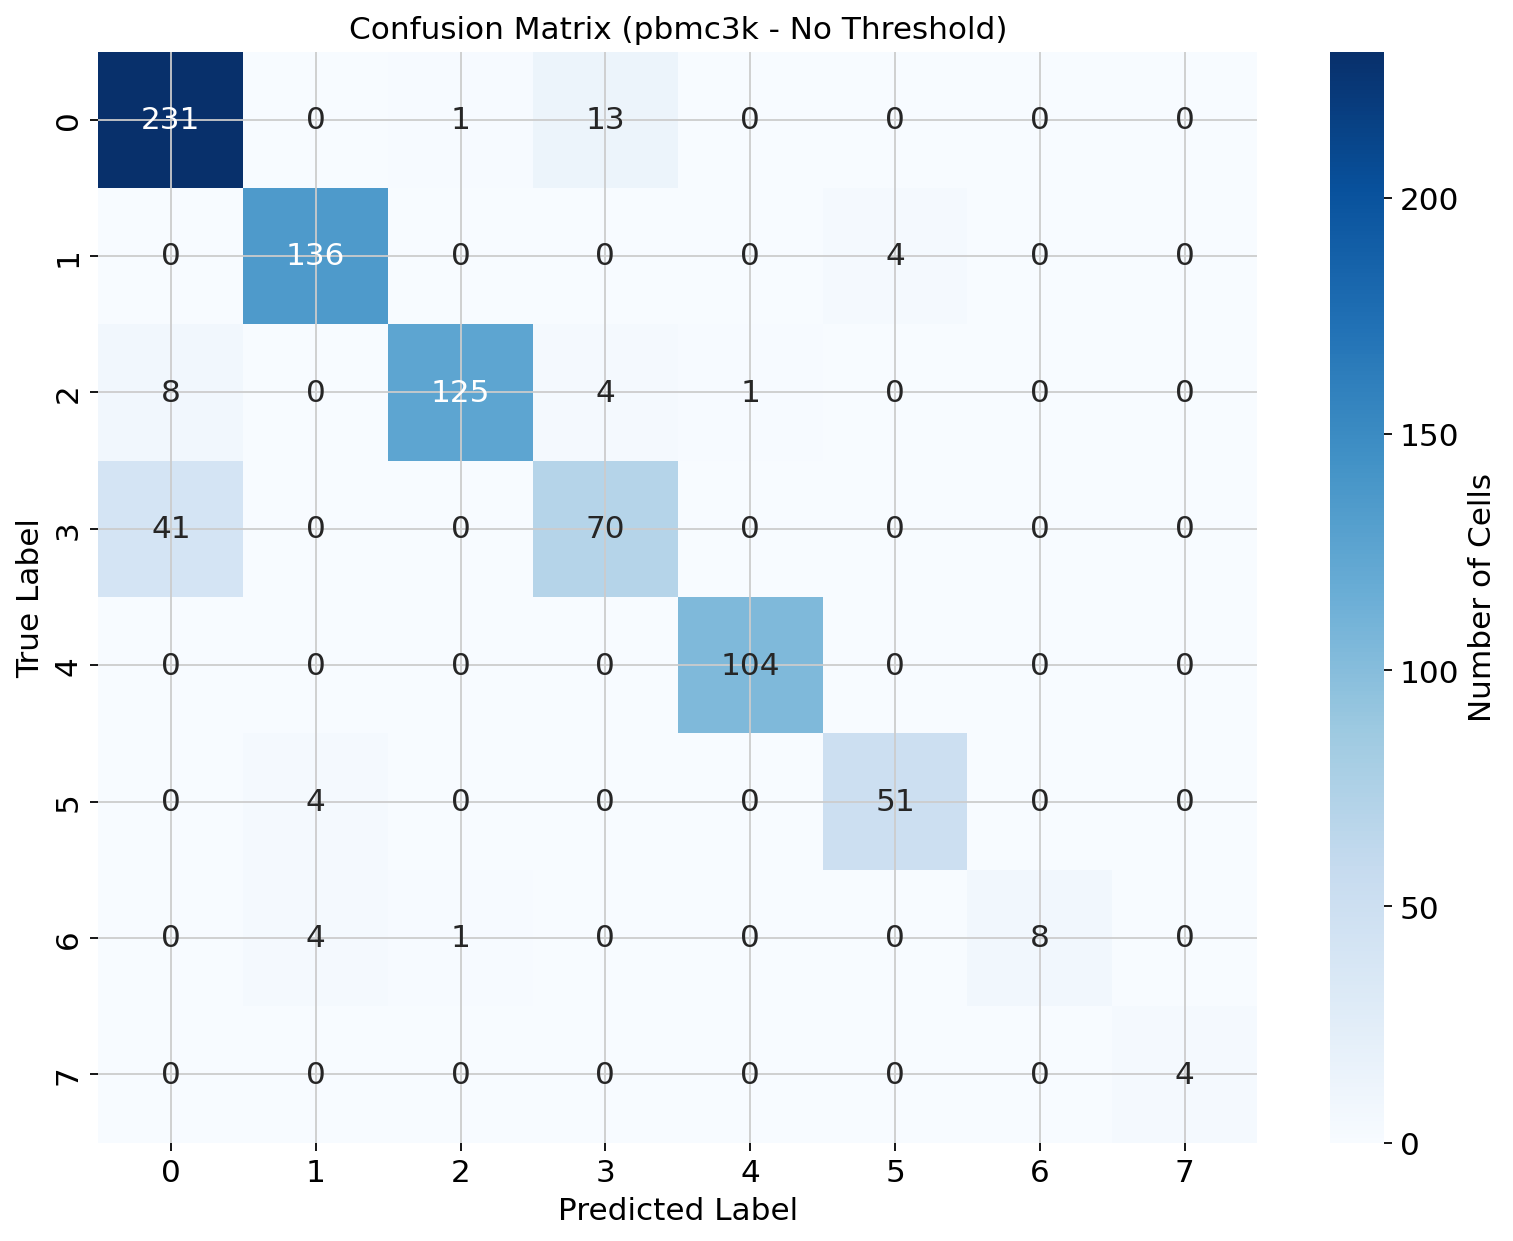


--- Per-Class ROC AUC (pbmc3k - No Threshold) ---


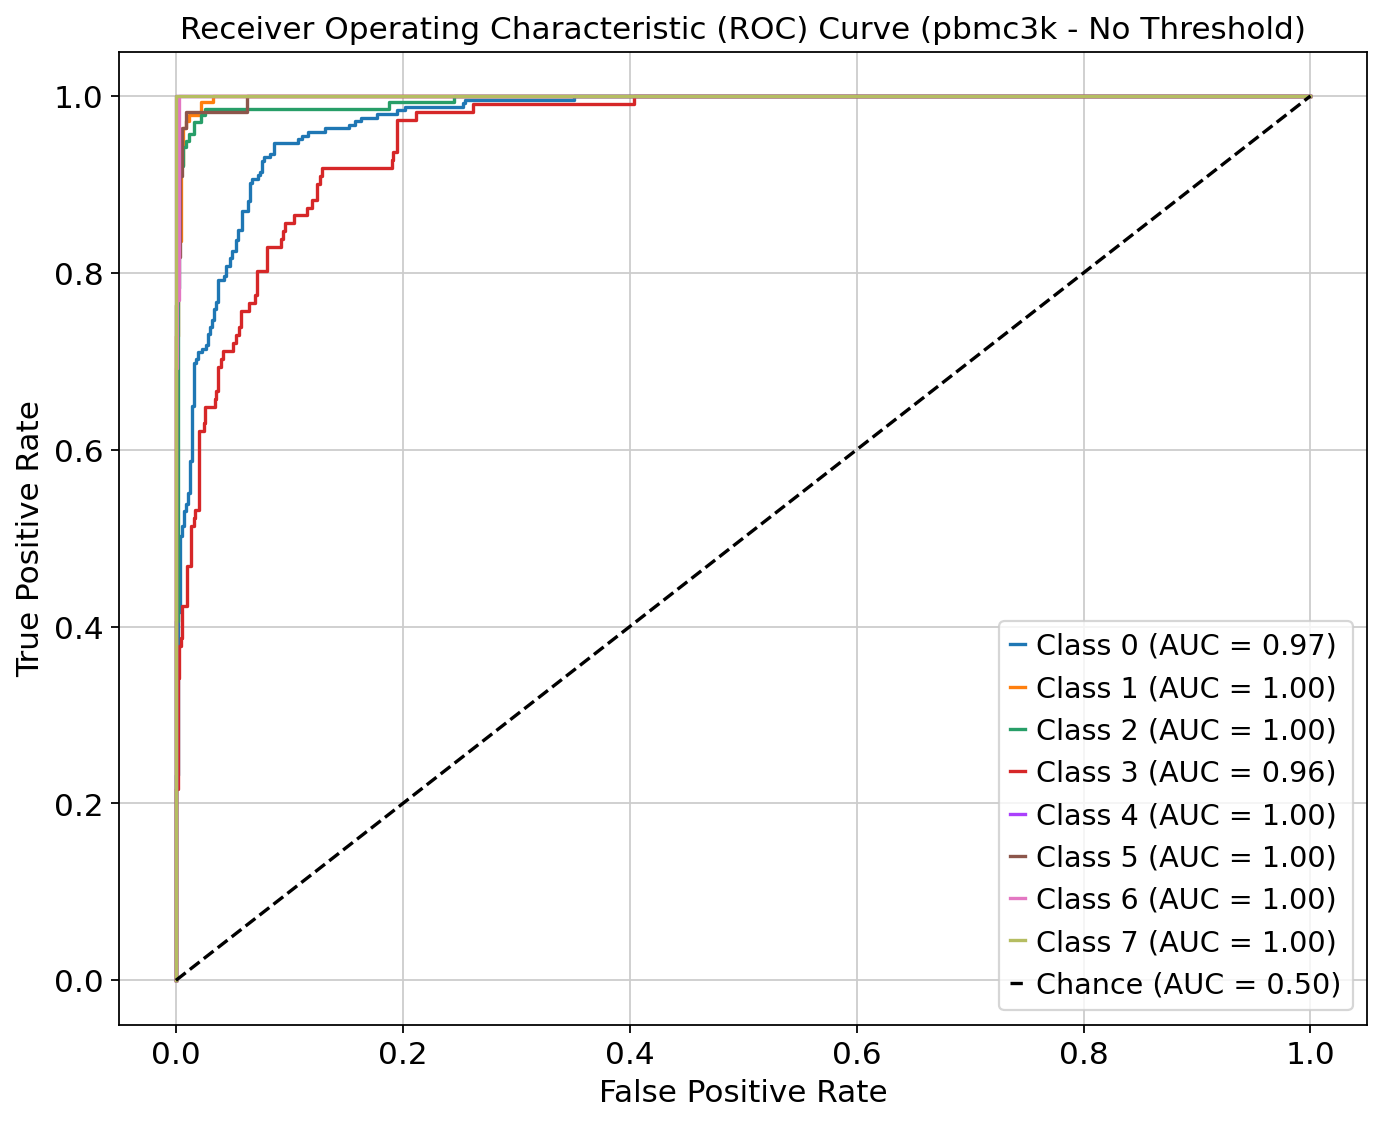


--- Distribution of Prediction Probabilities (pbmc3k - No Threshold) ---


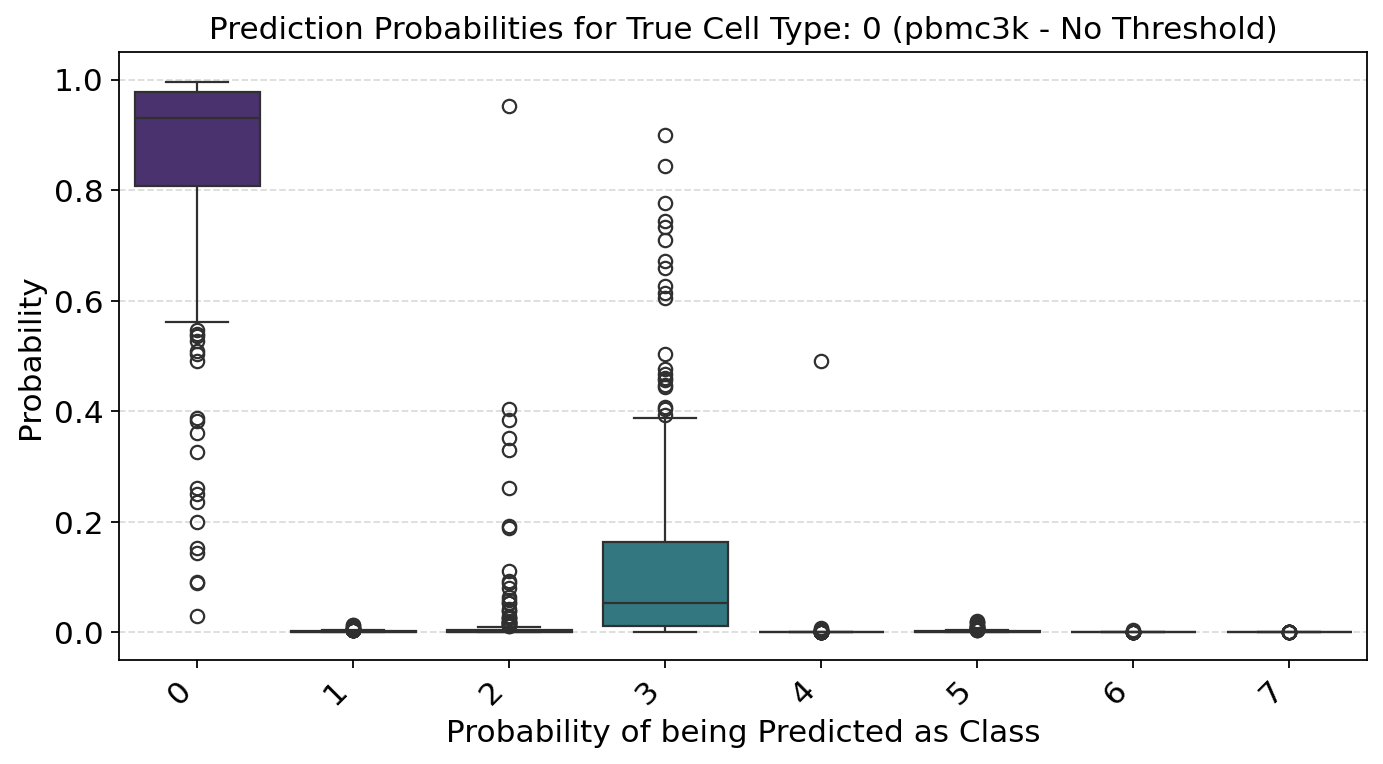

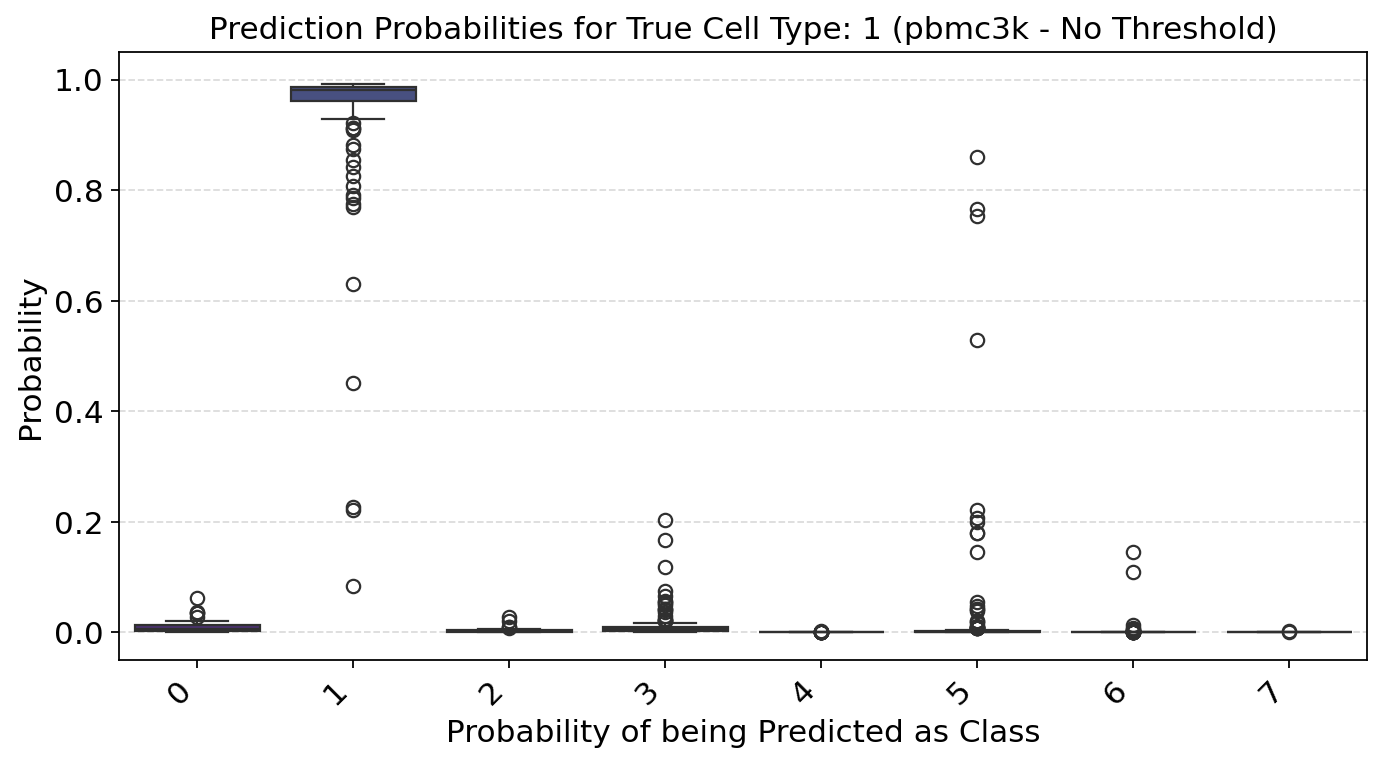

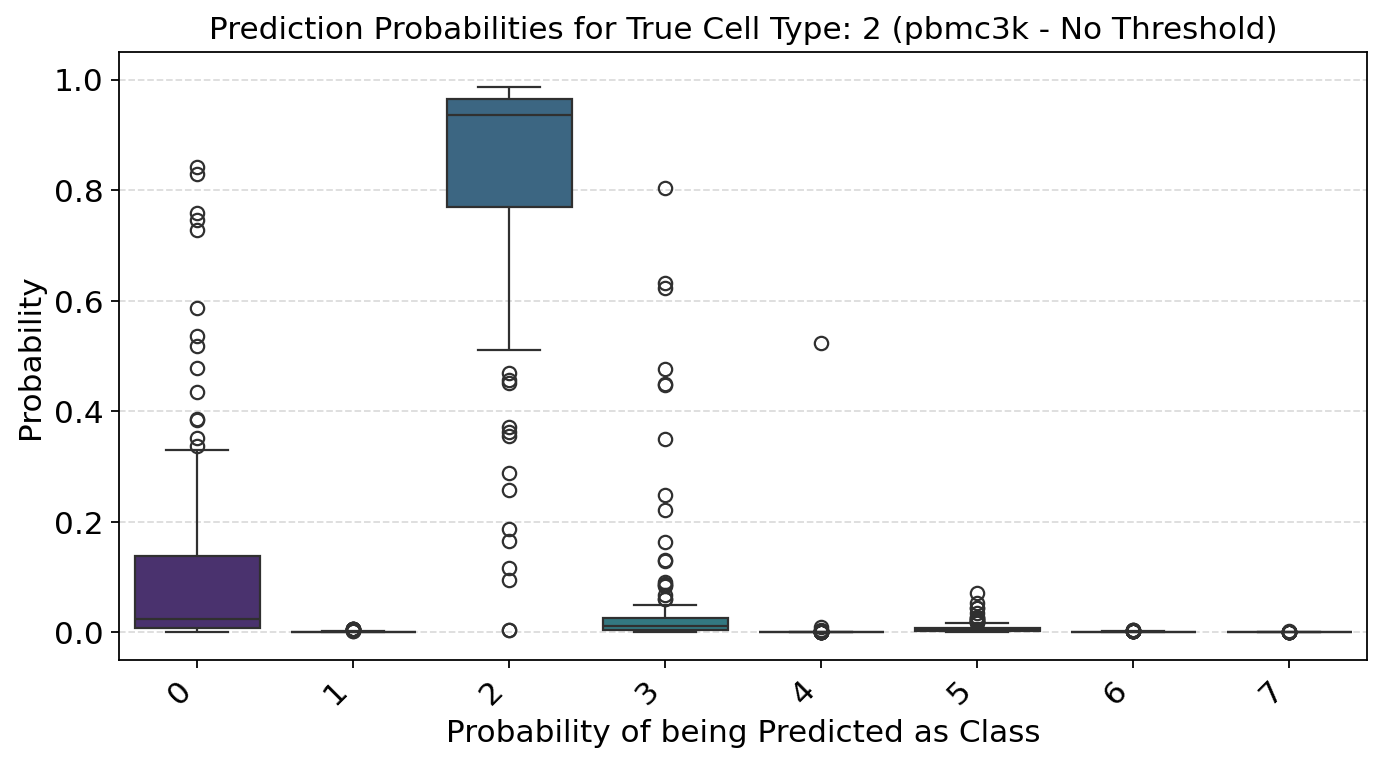

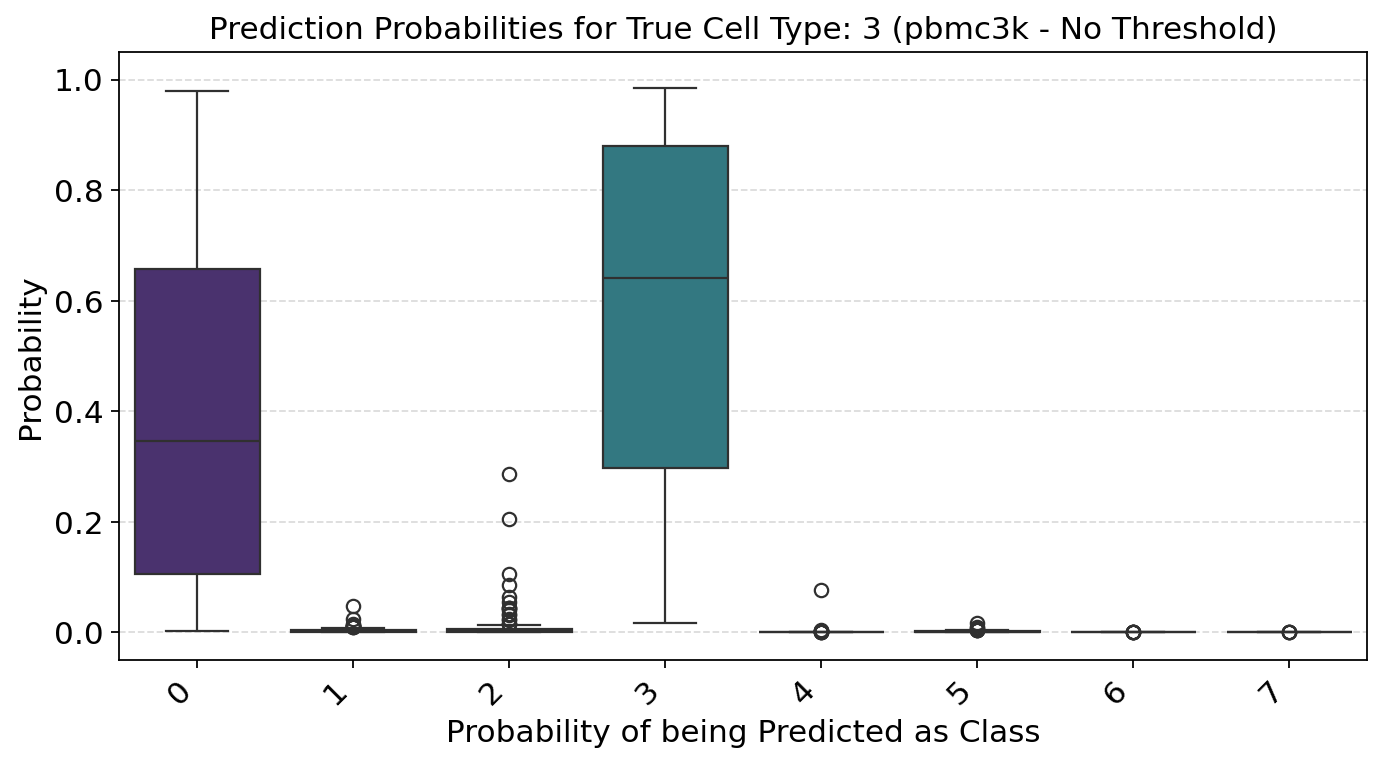

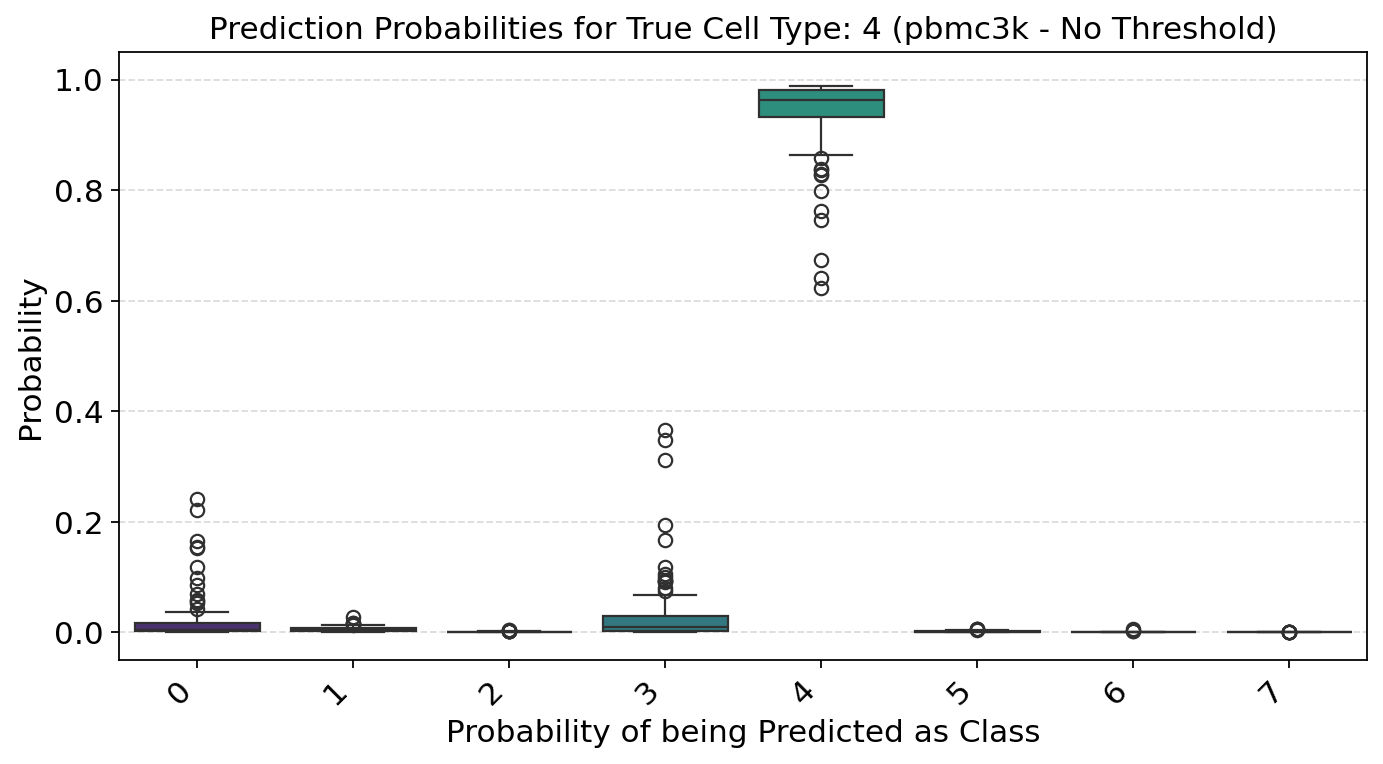

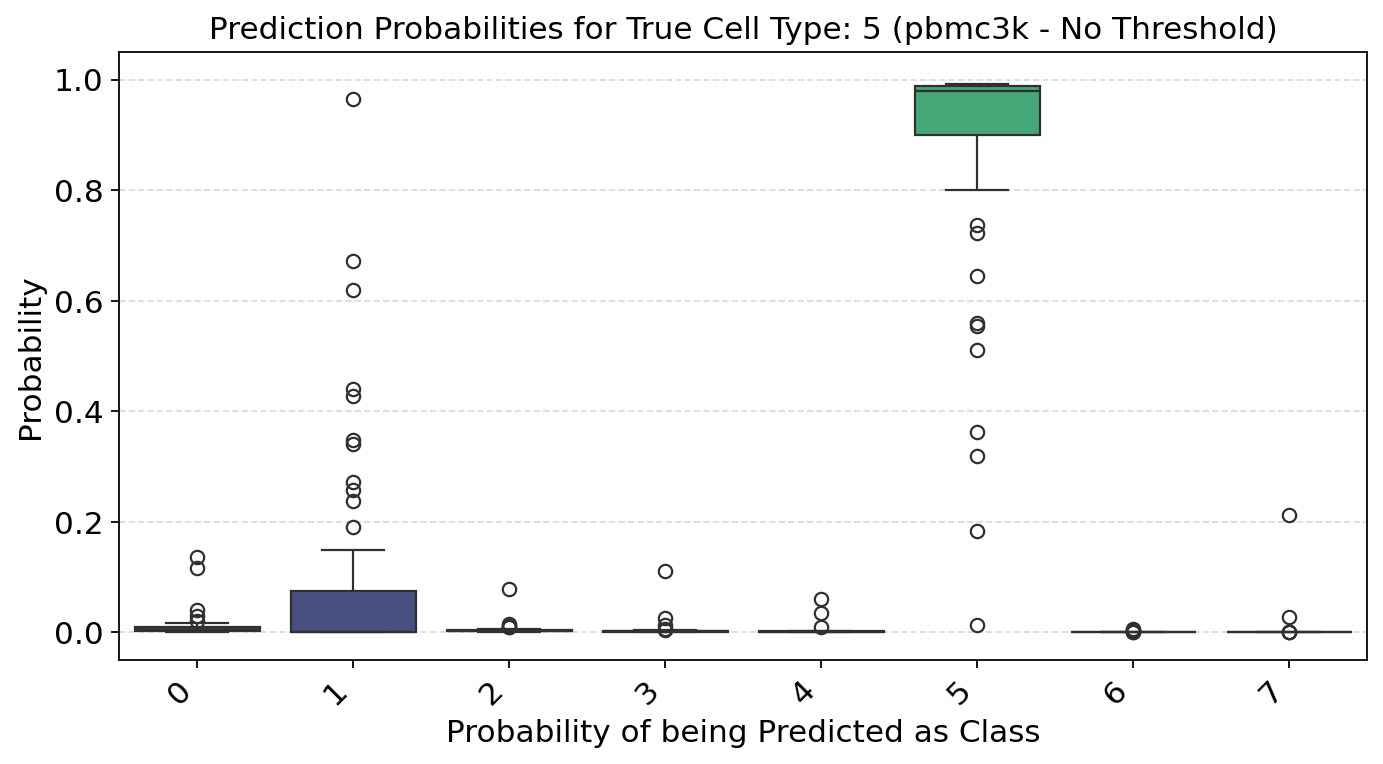

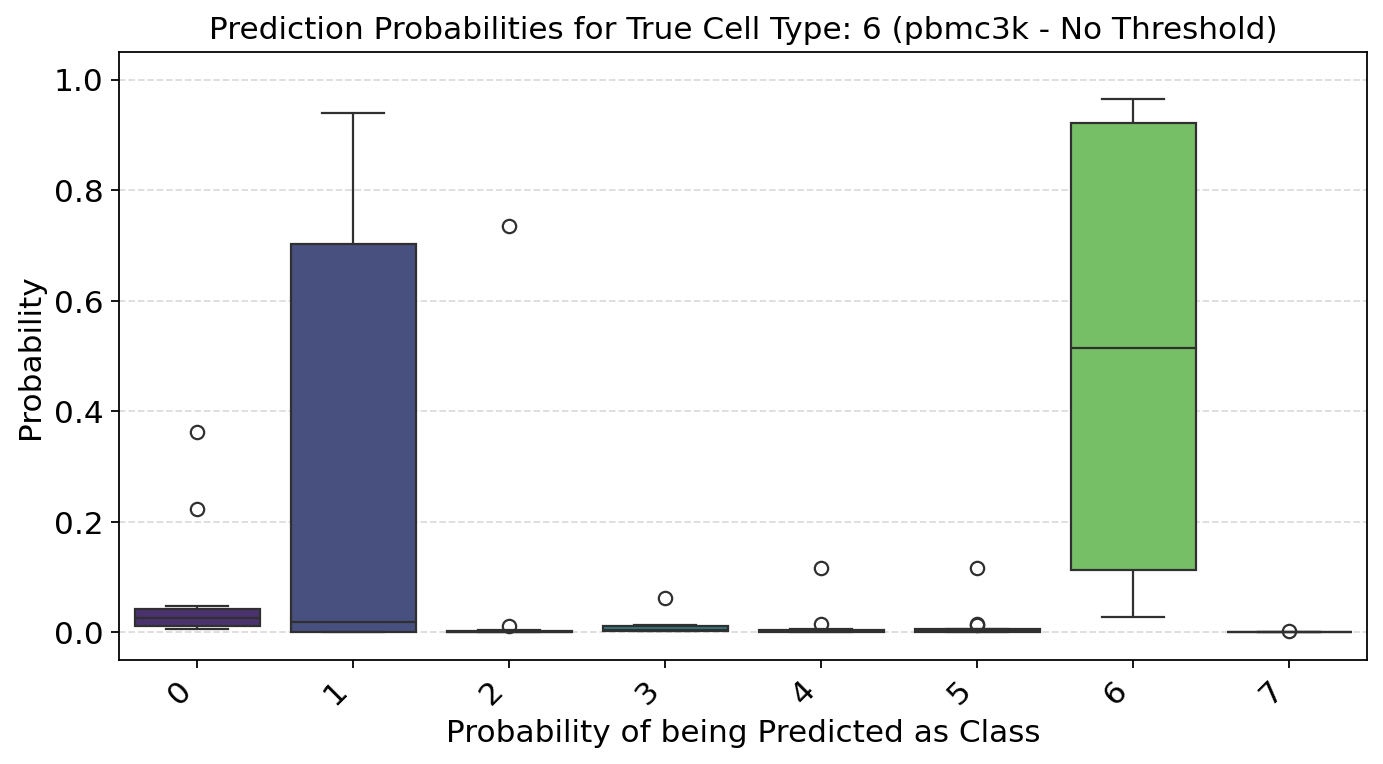

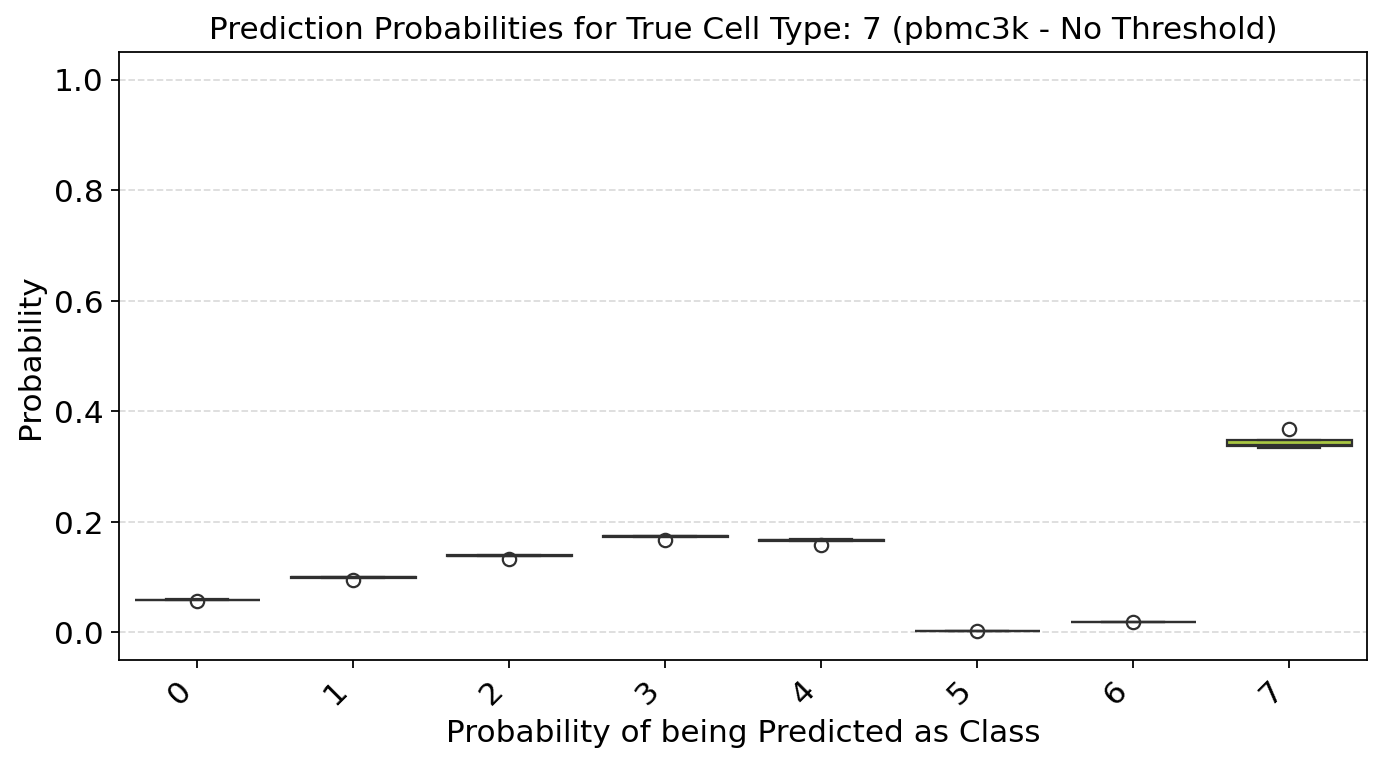


--- UMAP: True vs Predicted Labels (pbmc3k - No Threshold) ---


/tmp/ipykernel_32053/3933002330.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.03, 1, 0.98])


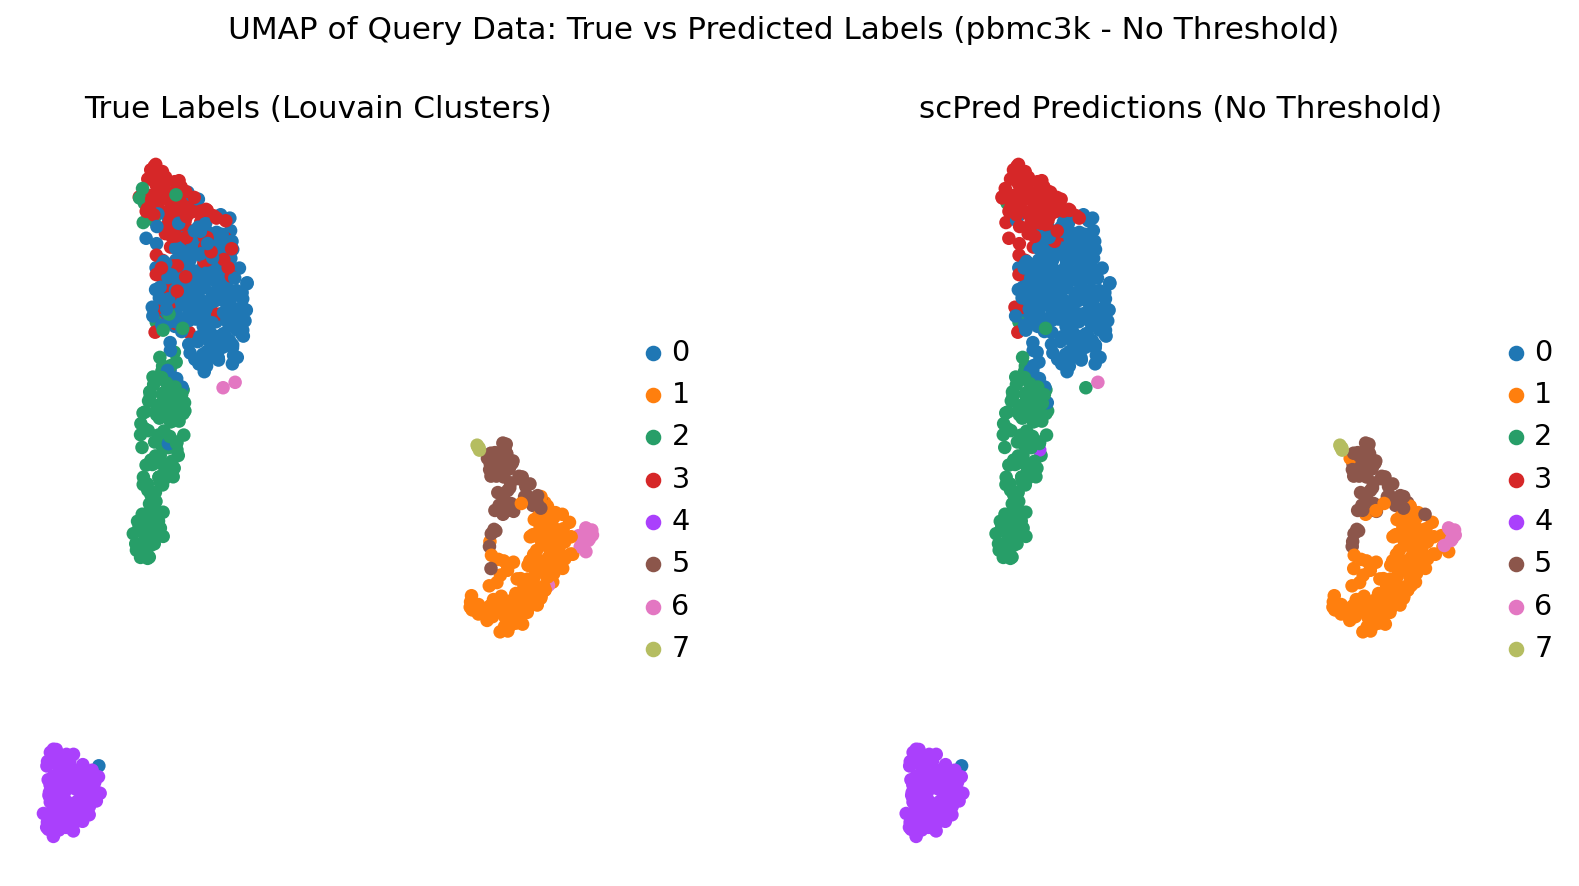


--- UMAP: Misclassified Cells (pbmc3k - No Threshold) ---


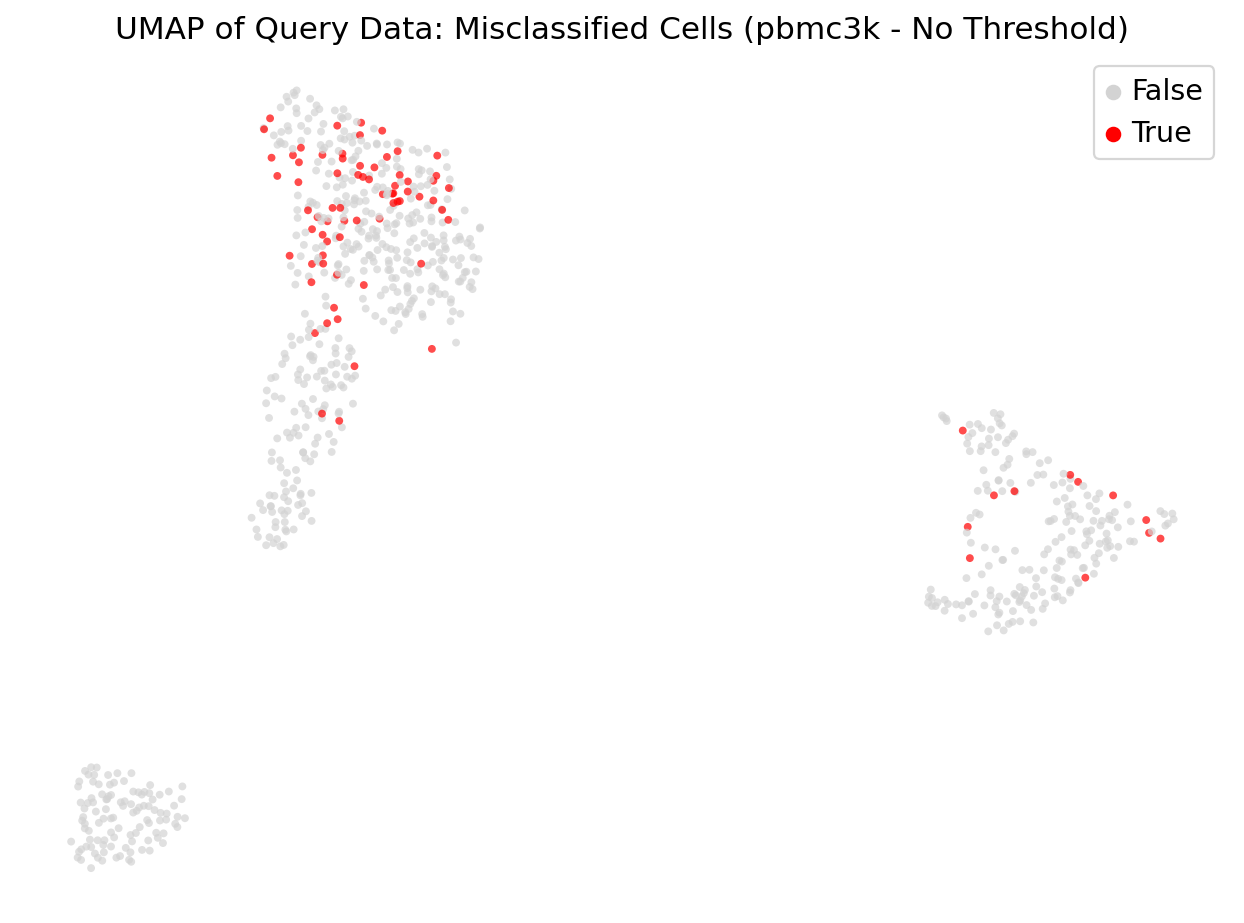


--- UMAP: Prediction Confidence (pbmc3k - No Threshold) ---


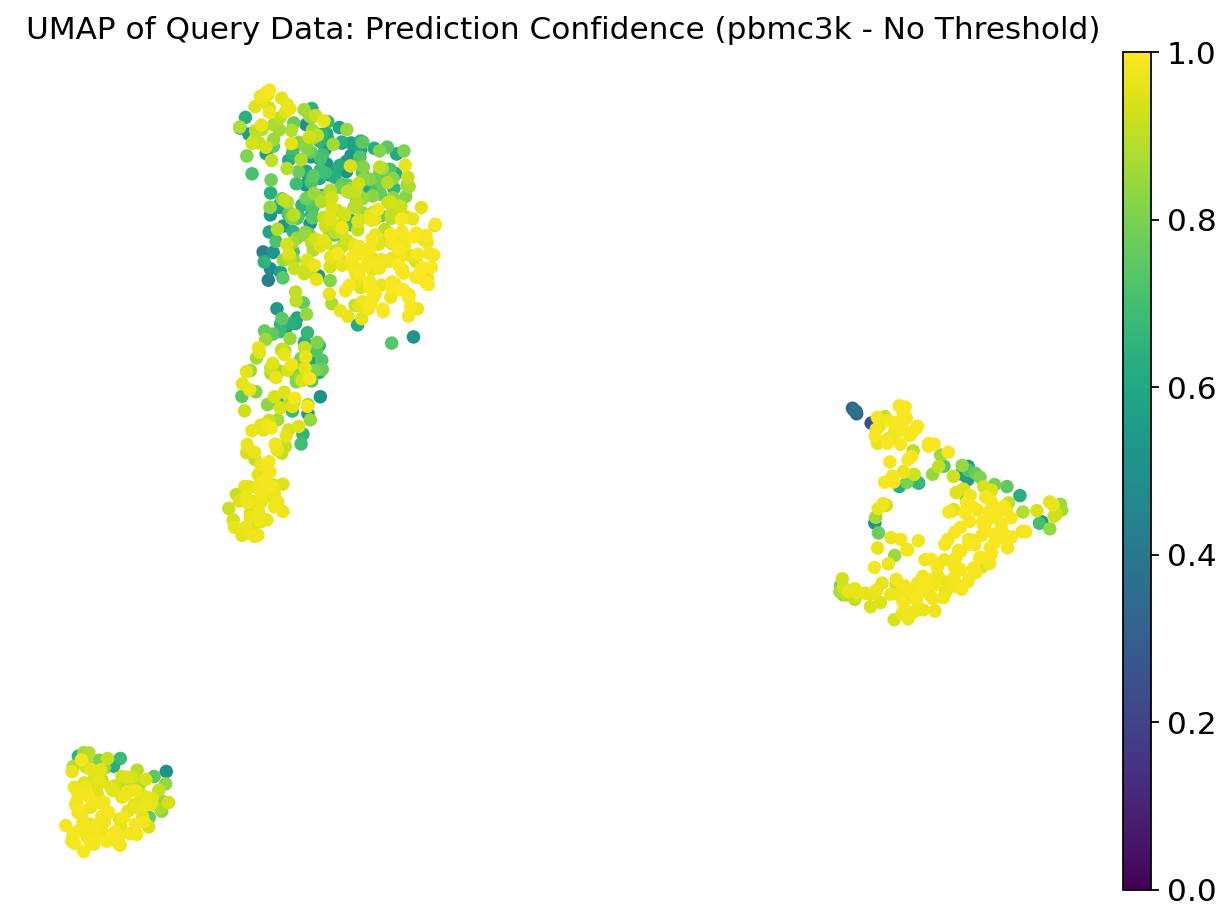



======== THOROUGH ANALYSIS: SCENARIO 2 - WITH THRESHOLD (threshold=0.8) ========

--- Step 4b: Predicting on Query Data (Threshold = 0.8) ---
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 11316 genes to 2000 reference genes...
  Note: 237 reference genes were missing in the query data and filled with zeros.
  Note: 9553 query genes were not in the reference and were dropped.
Genes aligned. New shape: (810, 2000)
Transforming data with fitted StandardScaler...
Data scaled.
Projecting data onto existing PCA space...
Projection finished.
Predicting cell types...
Applied probability thresholding: 173 cells set to 'unassigned' (threshold=0.8).
Prediction finished.
Projected PCs stored in query_adata.obsm['X_scpred_pca']. Cells filtered during preprocessing will have NaN values.
---

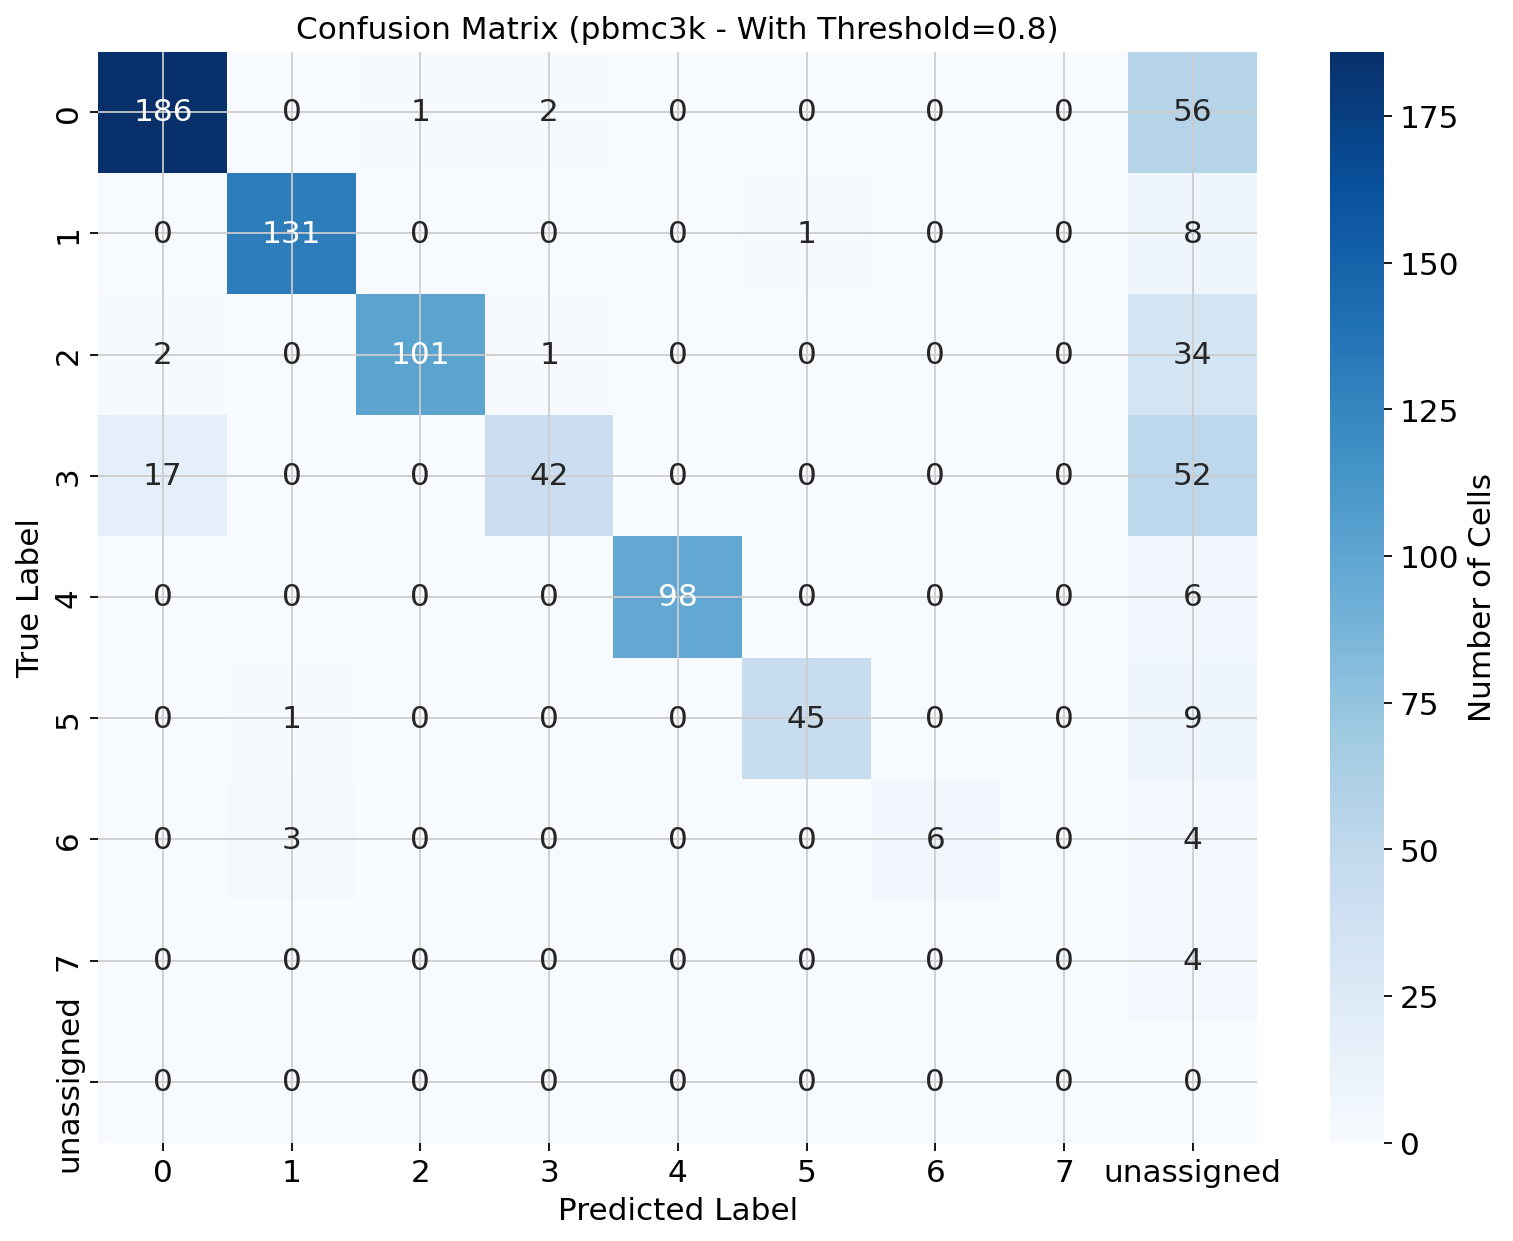


--- Per-Class ROC AUC (pbmc3k - With Threshold=0.8) ---


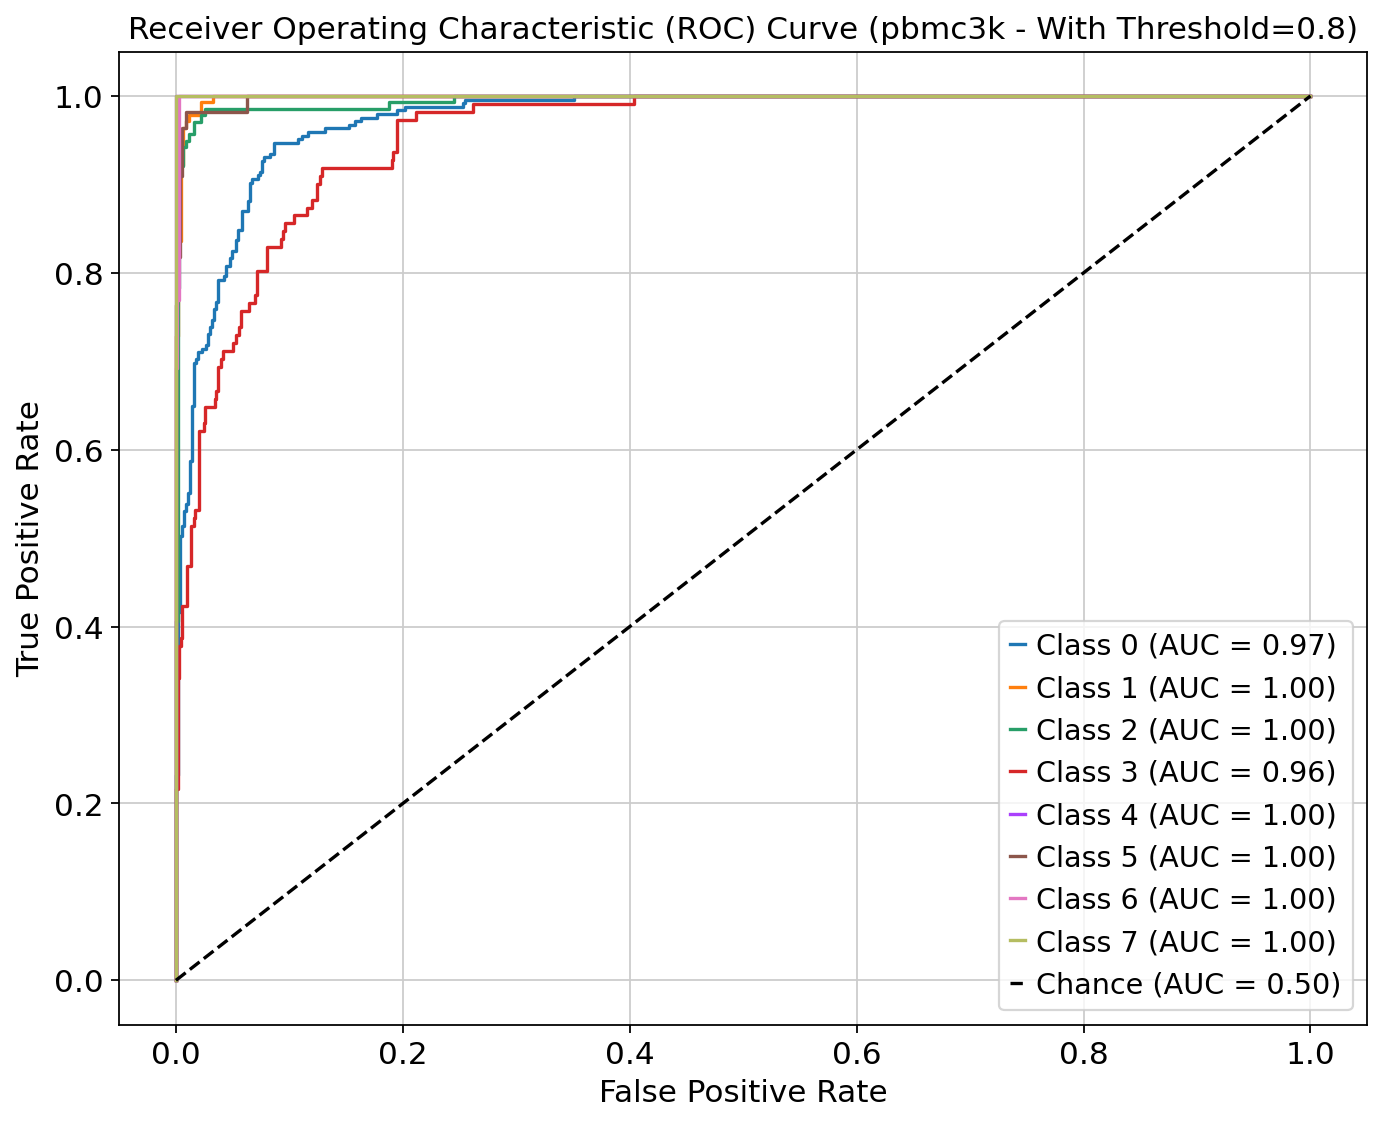


--- Distribution of Prediction Probabilities (pbmc3k - With Threshold=0.8) ---


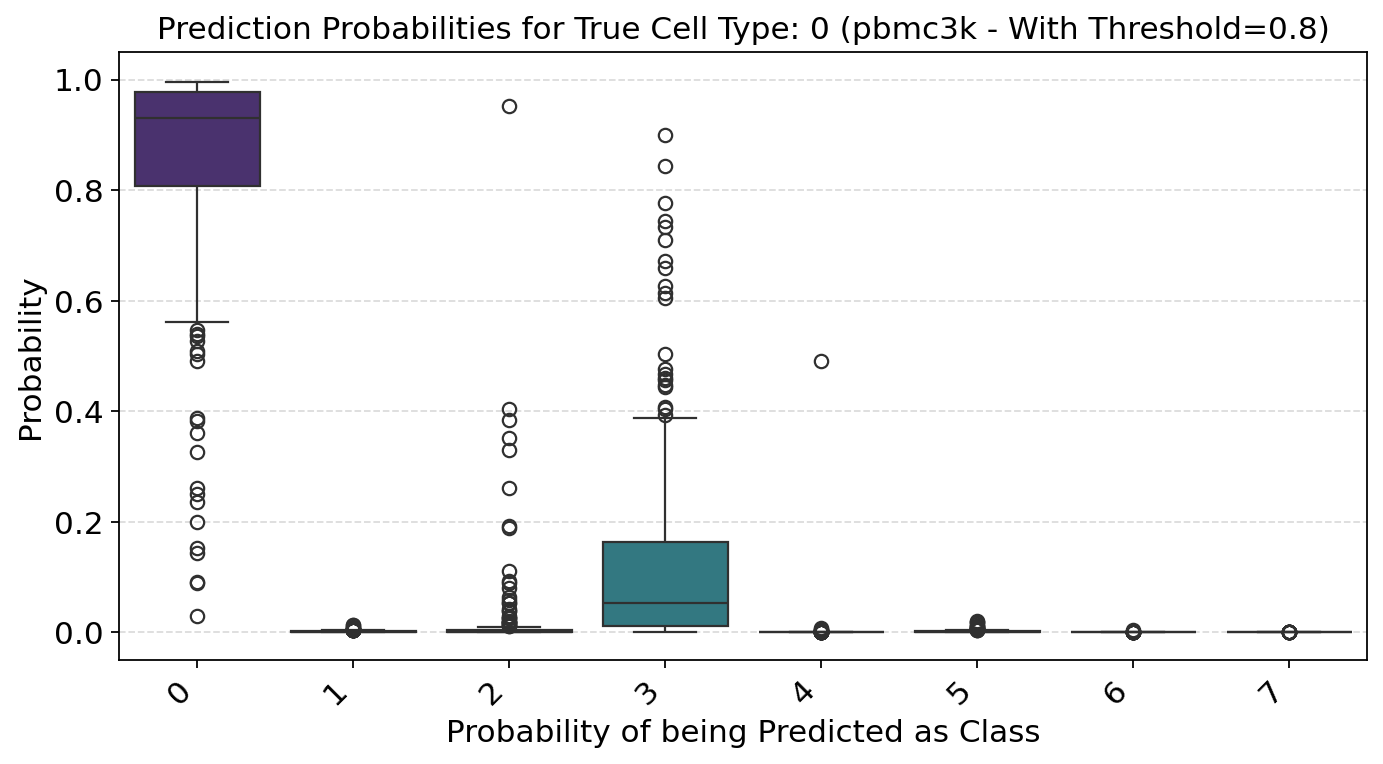

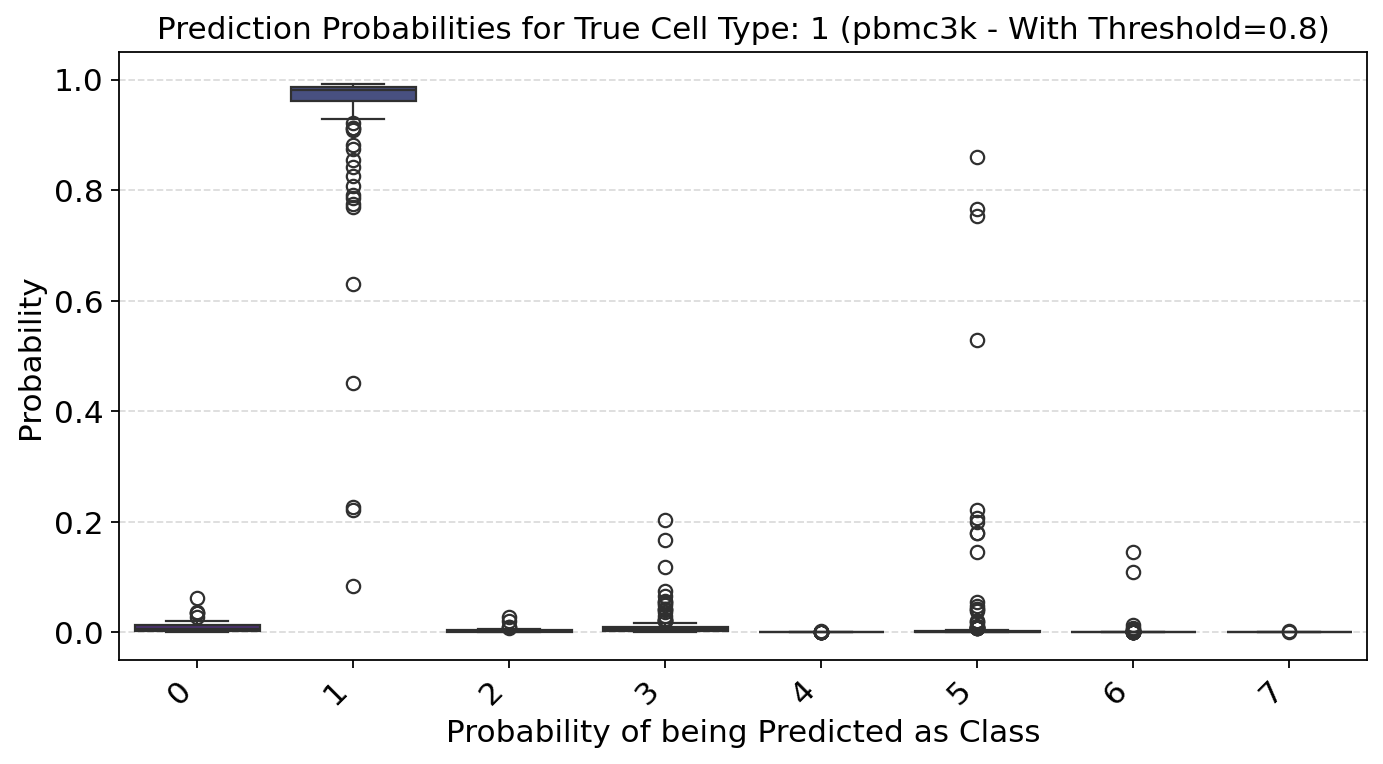

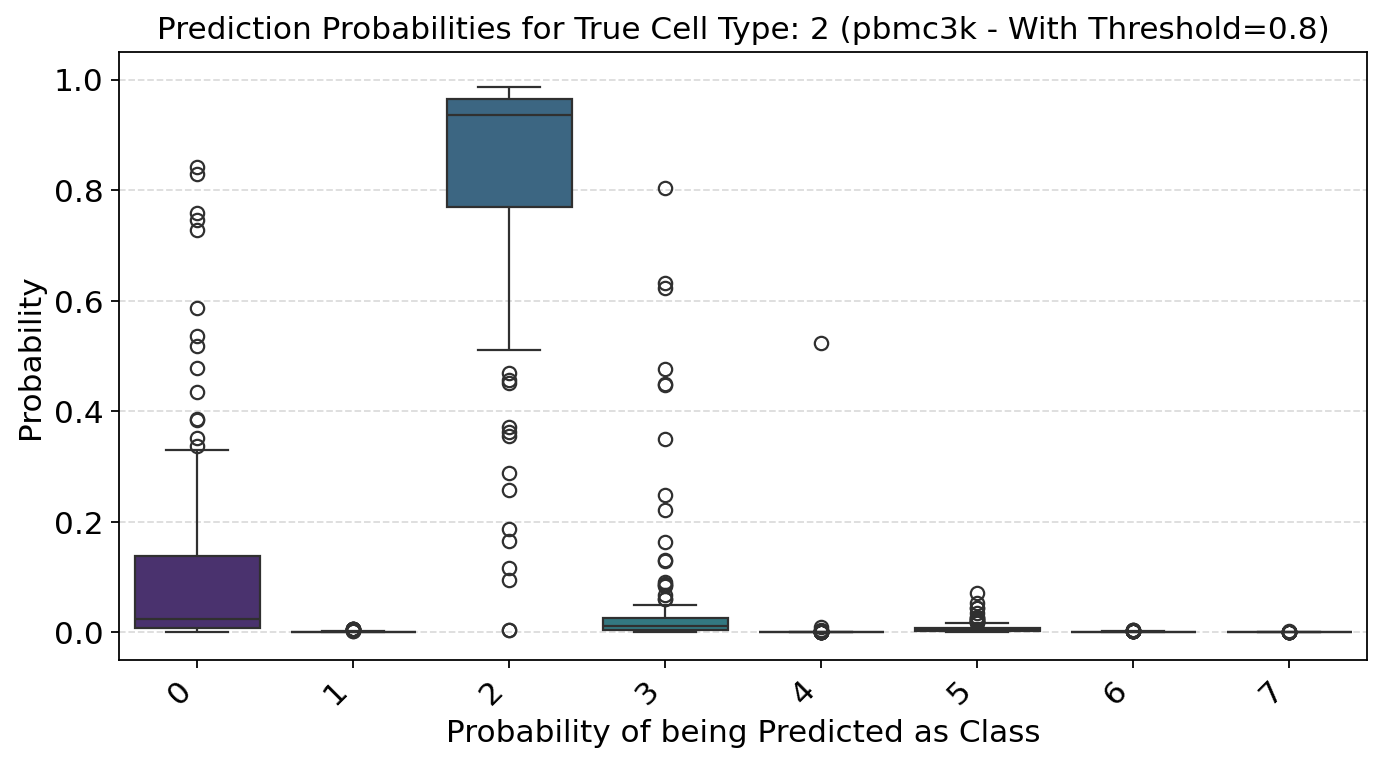

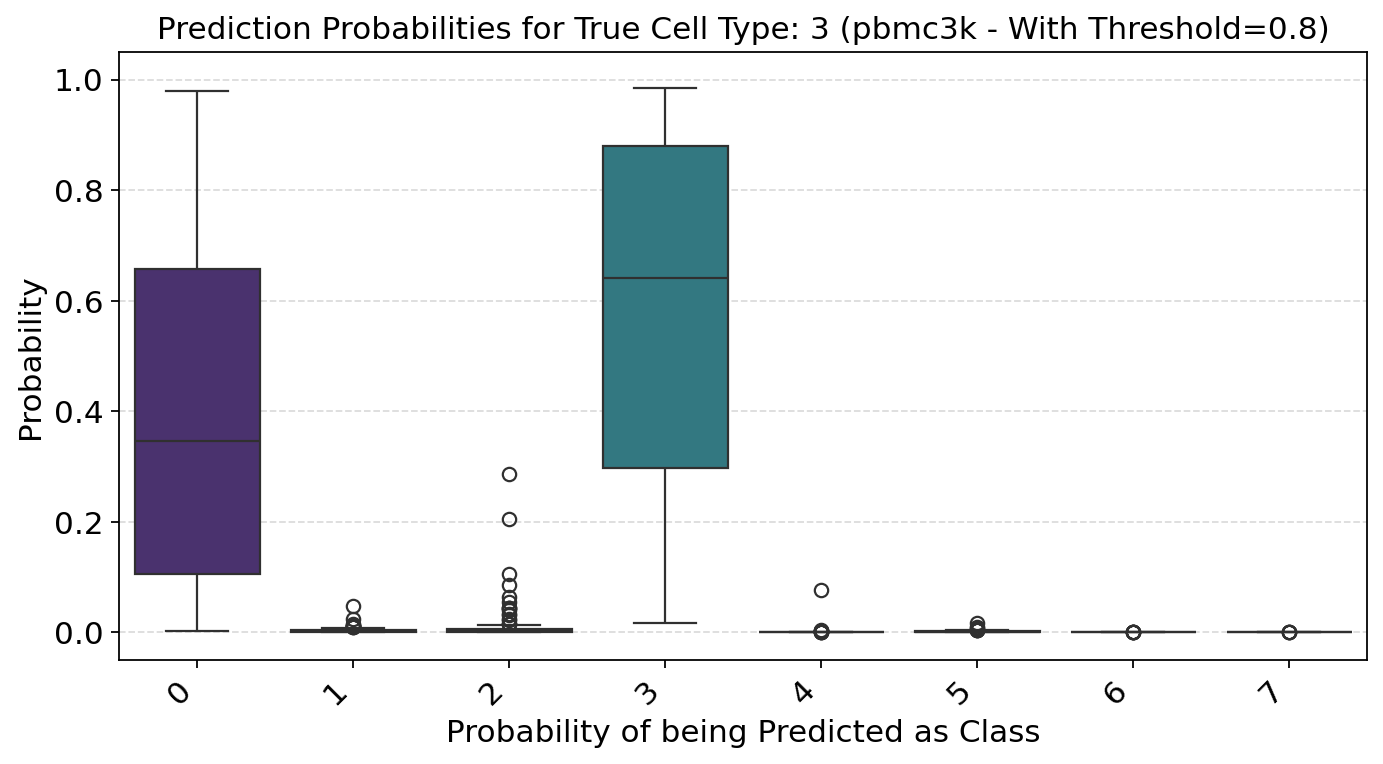

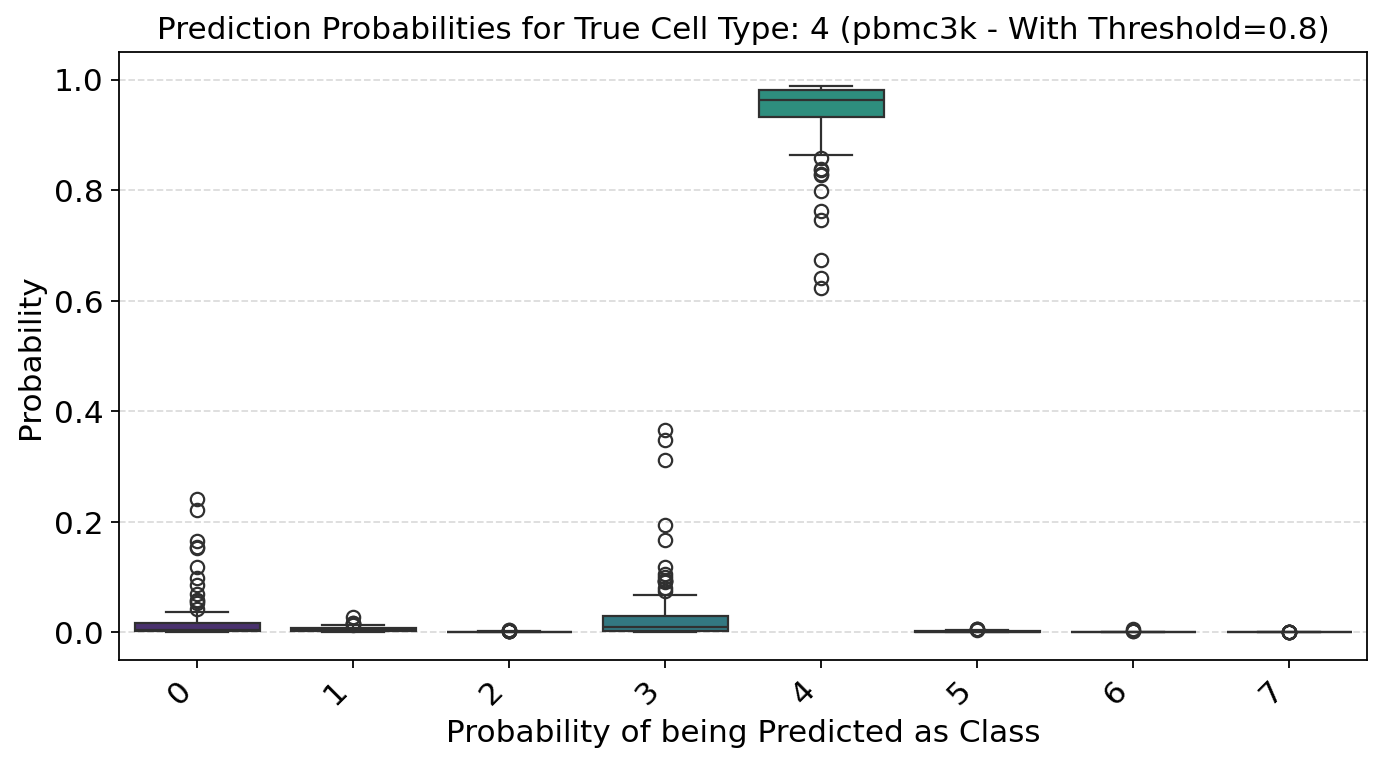

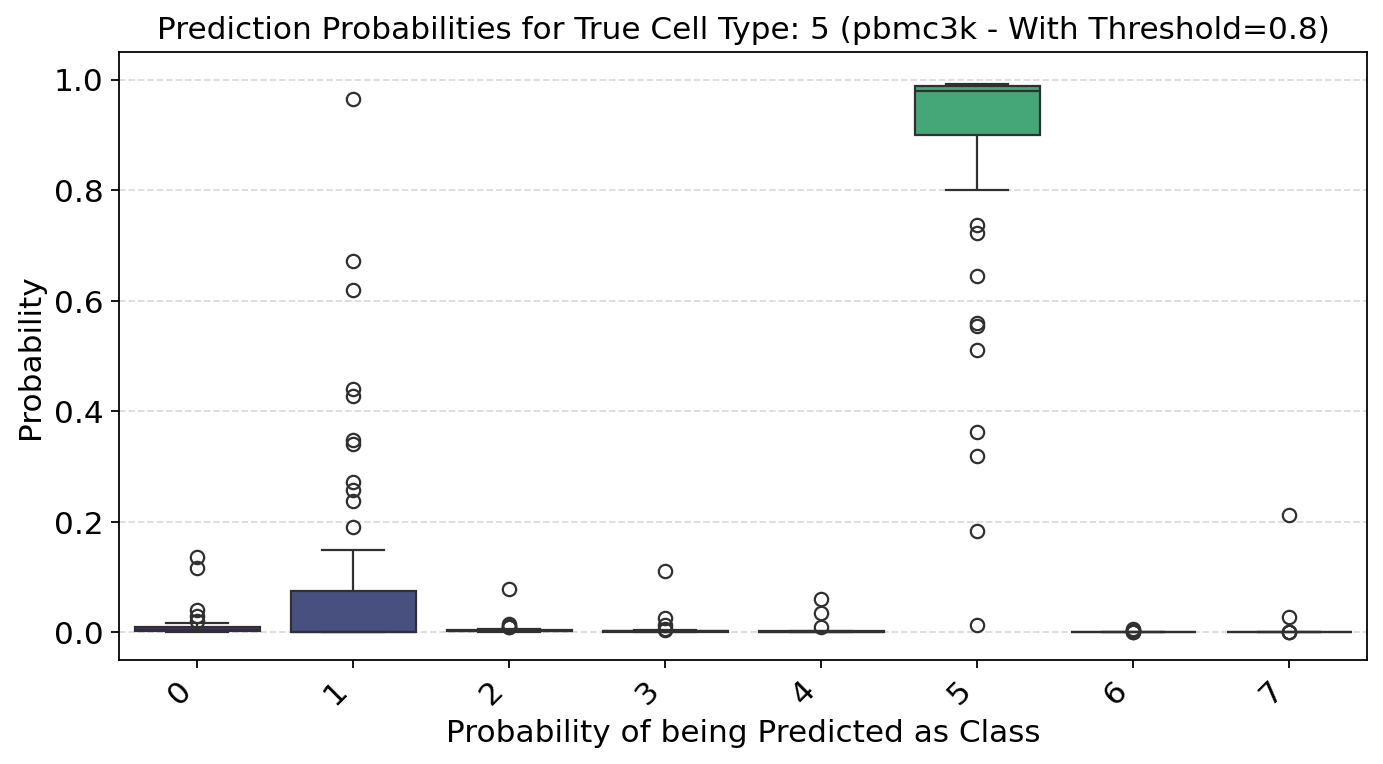

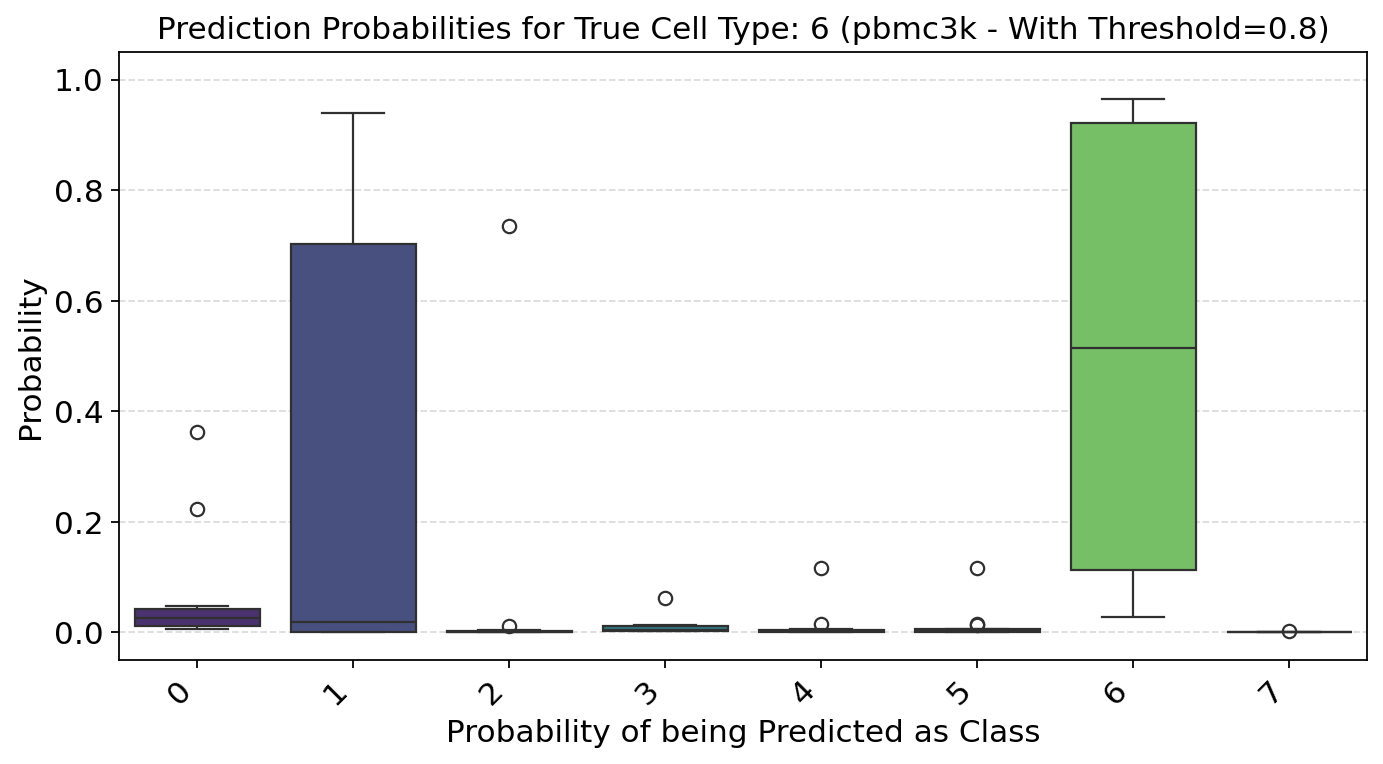

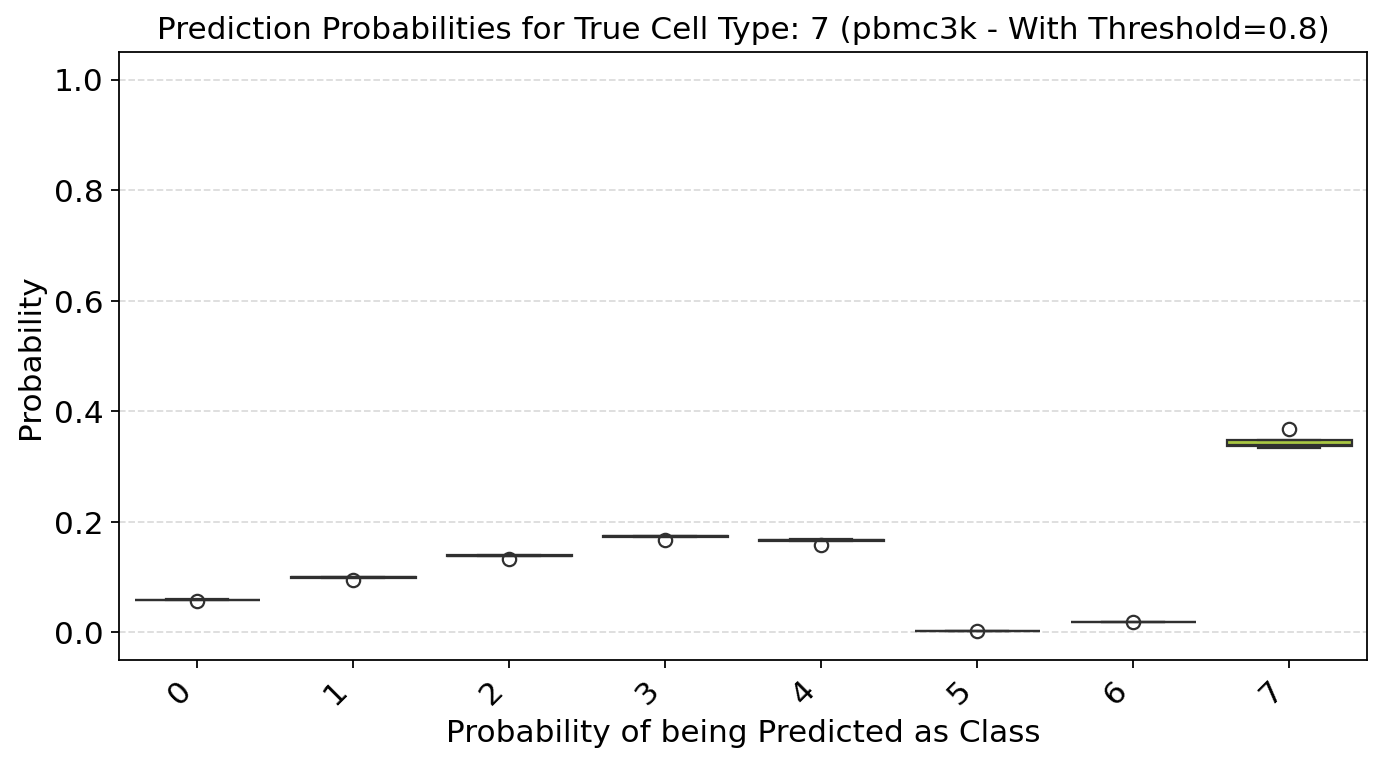


--- UMAP: True vs Predicted Labels (pbmc3k - With Threshold=0.8) ---


/tmp/ipykernel_32053/3933002330.py:502: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.03, 1, 0.98])


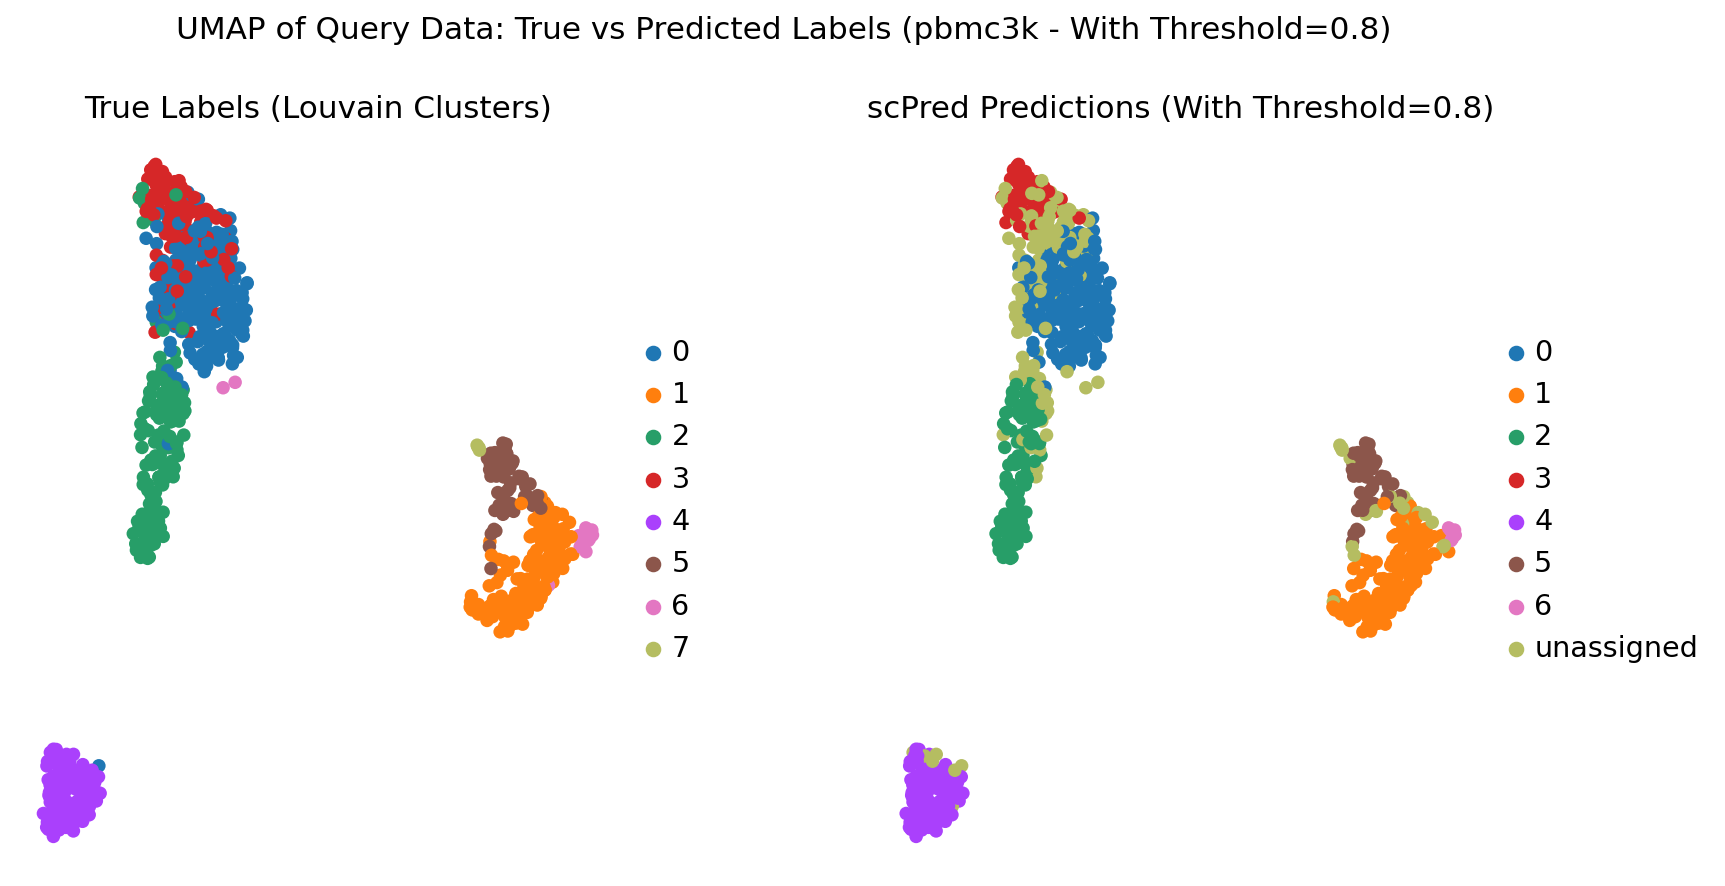


--- UMAP: Misclassified Cells (pbmc3k - With Threshold=0.8) ---


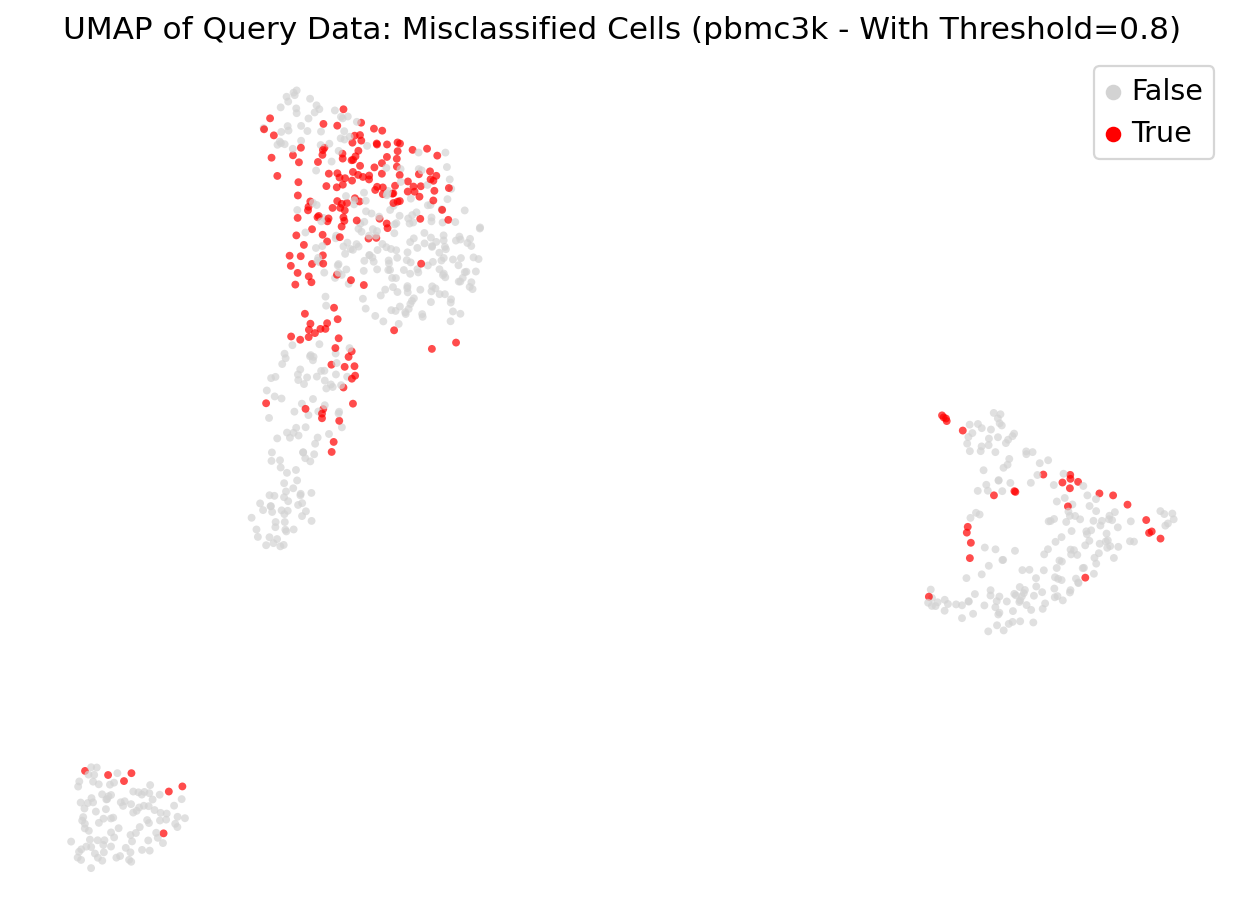


--- UMAP: Prediction Confidence (pbmc3k - With Threshold=0.8) ---


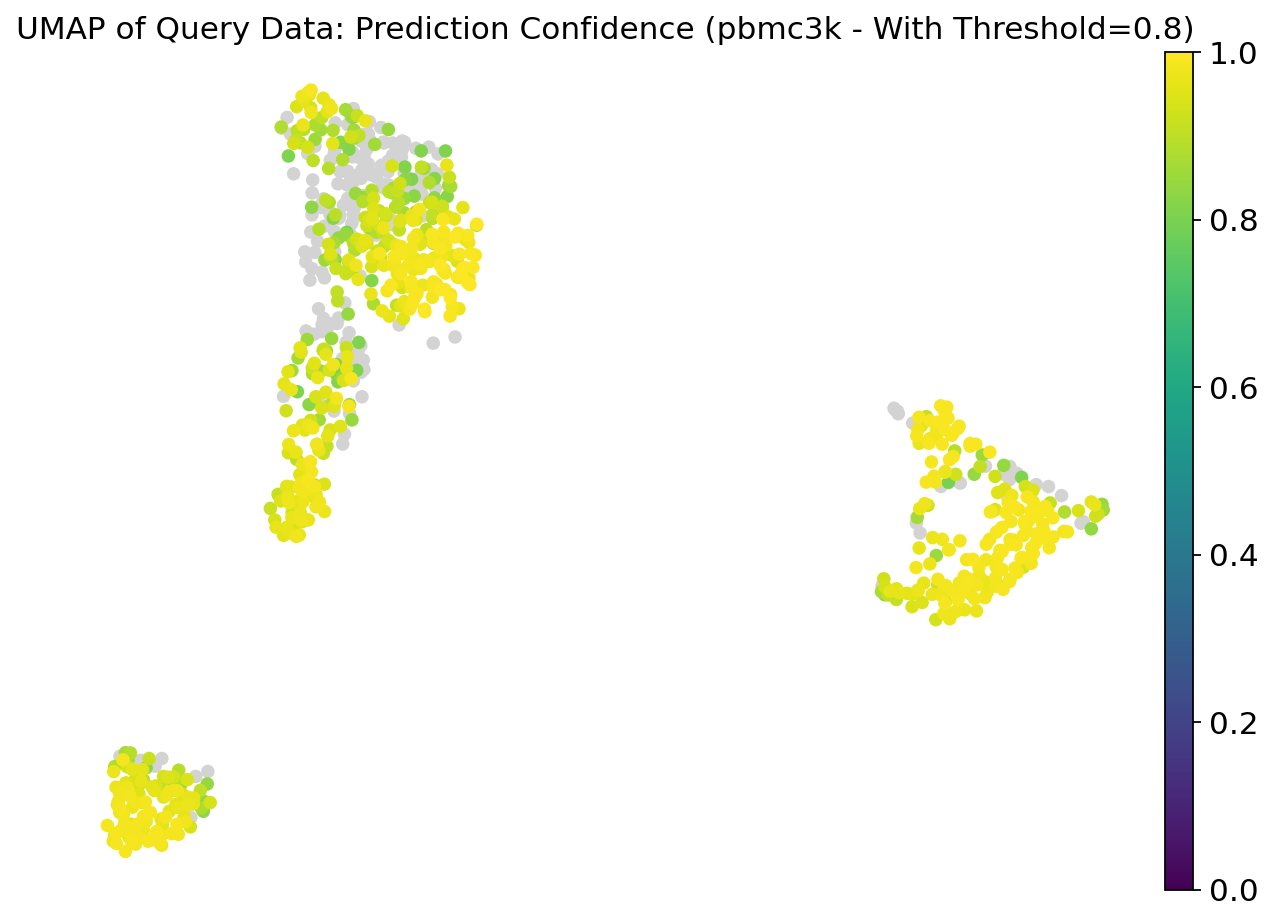


--- Analysis Complete ---


In [1]:
# --- 0. Imports and Setup ---
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import os
import pickle # For saving/loading models
import matplotlib.pyplot as plt
import seaborn as sns
import random # For setting Python's random seed

# Make sure you have these installed: pip install scikit-learn scikit-misc
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score
)
from sklearn.preprocessing import LabelBinarizer

# Adjust the path to import your scpred_py_final package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Importing the main ScPredModel class and utilities
from scpred_py_final import ScPredModel # Adjusted to scpred_py_final as per context
from scpred_py_final import _analysis_utils # Assuming _analysis_utils is part of the package


print("--- Setting up environment for reproducibility and file management ---")
# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE) # For Python's built-in random module
# Set Scanpy's random state for operations that support it
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(8, 8)) # Set initial figure params

# Define paths for saving
MODELS_DIR = '../models'
PREPROCESSED_DATA_DIR = '../data/preprocessed'

# Create directories if they don't exist
print(f"Ensuring directories exist: {MODELS_DIR} and {PREPROCESSED_DATA_DIR}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
print("Directories ensured.")


# --- 1. Data Loading and Initial Annotation ---
print("\n--- Step 1: Loading and Annotating Data ---")
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()

print(f"Initial raw AnnData object shape: {adata.shape}")
print(f"Initial raw AnnData .obs keys: {adata.obs.keys().tolist()}")
print(f"Initial raw AnnData .var keys: {adata.var.keys().tolist()}\n")


# Generate 'cell_type' labels using a temporary preprocessing pipeline
# This prepares the `adata` object with raw counts and the `cell_type` column
print("Generating temporary cell type labels via Louvain clustering...")
temp_adata_for_labels = adata.copy()
sc.pp.filter_cells(temp_adata_for_labels, min_genes=200)
sc.pp.filter_genes(temp_adata_for_labels, min_cells=3)
sc.pp.normalize_total(temp_adata_for_labels, target_sum=1e4)
sc.pp.log1p(temp_adata_for_labels)
sc.pp.highly_variable_genes(temp_adata_for_labels, min_mean=0.0125, max_mean=3, min_disp=0.5, flavor='seurat')
temp_adata_hvg_for_labels = temp_adata_for_labels[:, temp_adata_for_labels.var.highly_variable].copy()
sc.pp.scale(temp_adata_hvg_for_labels, max_value=10)
sc.tl.pca(temp_adata_hvg_for_labels, svd_solver='arpack', random_state=RANDOM_STATE) # Added random_state
sc.pp.neighbors(temp_adata_hvg_for_labels, n_neighbors=10, n_pcs=40, random_state=RANDOM_STATE) # Added random_state
sc.tl.louvain(temp_adata_hvg_for_labels, random_state=RANDOM_STATE, key_added='cell_type') # Added random_state

# Assign the generated cell_type labels back to the original raw adata object
adata.obs['cell_type'] = temp_adata_hvg_for_labels.obs['cell_type'].reindex(adata.obs_names).astype('category') # Ensure category type

print(f"Full dataset (raw counts + Louvain labels) shape: {adata.shape}")
print(f"Full dataset .obs keys after labeling: {adata.obs.keys().tolist()}")
print("Cell type distribution (all data):\n", adata.obs['cell_type'].value_counts())


# --- 2. Train-Test Split (Stratified) ---
# We split the raw data (with labels) into reference and query sets.
print("\n--- Step 2: Splitting Data (Stratified) ---")
indices = range(adata.n_obs)

ref_idx, query_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=RANDOM_STATE, # Ensuring split is reproducible
    stratify=adata.obs['cell_type'] # CRITICAL for balanced classes
)

# These AnnData objects contain raw counts and cell_type labels.
# The ScPredModel will handle their internal preprocessing.
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()

print(f"Reference data (raw + labels) shape: {ref_adata_raw.shape}")
print(f"Query data (raw + labels) shape: {query_adata_raw.shape}")
print("\nReference cell type distribution:\n", ref_adata_raw.obs['cell_type'].value_counts())
print("\nQuery cell type distribution:\n", query_adata_raw.obs['cell_type'].value_counts())


# Calculate and report class imbalance
print("\n--- Class Imbalance Analysis ---")
print("Reference data class imbalance (proportion):\n", ref_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())
print("Query data class imbalance (proportion):\n", query_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())


# --- 3. Training the scPred Model (with Optimal Parameters) ---
# The ScPredModel will now handle all preprocessing (normalization, log1p, HVG, scaling, PCA) internally.
print("\n--- Step 3: Training scPred Model with Optimal Parameters ---")
scpred_model = ScPredModel()

# Applying optimal parameters from Notebook 02's comparative analysis (Exp 15 for pbmc3k)
# (RBF kernel, C=10.0, No class weight, 2000 HVGs, 30 PCs)
scpred_model.train(
    ref_adata=ref_adata_raw, # Pass the raw reference data with generated cell_type annotations
    cell_type_key='cell_type',
    n_components=30, # Optimal from N02's Exp 15
    hvg_n_top_genes=2000, # Optimal from N02's Exp 15
    hvg_flavor='seurat', # Consistent with N02
    svm_kernel='rbf', # Optimal from N02's Exp 15
    svm_c=10.0, # Optimal from N02's Exp 15
    svm_random_state=RANDOM_STATE, # Ensuring SVM training is reproducible
    svm_class_weight=None # Optimal from N02's Exp 15
)

print("\nModel Trained with Optimal Parameters!")
print(f"Scaler: {scpred_model.scaler_}")
print(f"PCA Model: {scpred_model.pca_model_}")
print(f"Classifier: {scpred_model.classifier_}")
print(f"Reference HVGs learned: {len(scpred_model.reference_hvg_genes_)} genes")

# Save the trained ScPredModel object
model_path = os.path.join(MODELS_DIR, 'scpred_model_pbmc3k_optimal.pkl')
scpred_model.save(model_path)
print(f"Optimal ScPredModel saved successfully to: {model_path}")

# Save the preprocessed reference data (now accessible via scpred_model.ref_adata_processed_)
if hasattr(scpred_model, 'ref_adata_processed_') and scpred_model.ref_adata_processed_ is not None:
    preprocessed_ref_path = os.path.join(PREPROCESSED_DATA_DIR, 'pbmc3k_ref_preprocessed_optimal.h5ad')
    scpred_model.ref_adata_processed_.write(preprocessed_ref_path)
    print(f"Preprocessed reference data saved to: {preprocessed_ref_path}")
else:
    print("Warning: scpred_model.ref_adata_processed_ is None. Preprocessed reference data not saved.")


# ==============================================================================
# THOROUGH ANALYSIS: SCENARIO 1 - NO THRESHOLD (threshold=0.0)
# ==============================================================================
print("\n\n======== THOROUGH ANALYSIS: SCENARIO 1 - NO THRESHOLD (threshold=0.0) ========")

# --- 4a. Predicting with the scPred Model (Threshold = 0.0) ---
print("\n--- Step 4a: Predicting on Query Data (Threshold = 0.0) ---")
query_adata_pred_no_threshold = scpred_model.predict(query_adata_raw.copy(), threshold=0.0) # Pass a copy

print("\nQuery Data with Predictions (No Threshold, first 5 rows):")
print(query_adata_pred_no_threshold.obs[['cell_type', 'scpred_prediction']].head())
print(f"\nQuery data .obs keys after prediction: {query_adata_pred_no_threshold.obs.keys().tolist()}")
print(f"Query data .obsm keys after prediction: {list(query_adata_pred_no_threshold.obsm.keys())}")
print("\nPredicted label distribution (No Threshold):\n", query_adata_pred_no_threshold.obs['scpred_prediction'].value_counts(dropna=False))

# Save the preprocessed query data with predictions
preprocessed_query_no_threshold_path = os.path.join(PREPROCESSED_DATA_DIR, 'pbmc3k_query_pred_no_threshold.h5ad')
query_adata_pred_no_threshold.write(preprocessed_query_no_threshold_path)
print(f"Preprocessed query data with predictions (No Threshold) saved to: {preprocessed_query_no_threshold_path}")


# --- 5a. Evaluating Predictions (Threshold = 0.0) ---
true_labels_no_threshold = query_adata_pred_no_threshold.obs['cell_type']
predicted_labels_no_threshold = query_adata_pred_no_threshold.obs['scpred_prediction']

# Filter out NaN predictions for evaluation to avoid ValueError
valid_cells_no_threshold = predicted_labels_no_threshold.notna()
true_labels_no_threshold_filtered = true_labels_no_threshold[valid_cells_no_threshold]
predicted_labels_no_threshold_filtered = predicted_labels_no_threshold[valid_cells_no_threshold]

pred_prob_cols_no_threshold = [col for col in query_adata_pred_no_threshold.obs.columns if col.startswith('scpred_prob_')]
y_pred_probs_df_no_threshold = None
if len(pred_prob_cols_no_threshold) > 0:
    y_pred_probs_df_no_threshold = query_adata_pred_no_threshold.obs.loc[valid_cells_no_threshold, pred_prob_cols_no_threshold].copy()
    y_pred_probs_df_no_threshold = y_pred_probs_df_no_threshold.fillna(0.0)


print("\n--- Evaluation for No Threshold Model ---")
metrics_results_no_threshold = _analysis_utils.evaluate_and_report_metrics(
    true_labels=true_labels_no_threshold_filtered,
    predicted_labels=predicted_labels_no_threshold_filtered,
    classifier_classes=scpred_model.classifier_.classes_,
    y_pred_probs=y_pred_probs_df_no_threshold
)


# --- 6a. Visualizing Results (Threshold = 0.0) ---
print("\n--- Step 6a: Visualizing Results (Threshold = 0.0) ---")

# For UMAP plots, we need the AnnData object to be filtered to only valid cells or handle NaNs in plots.
query_adata_pred_no_threshold_filtered_for_umap = query_adata_pred_no_threshold[valid_cells_no_threshold, :].copy()

if 'iroot' in query_adata_pred_no_threshold_filtered_for_umap.uns:
    del query_adata_pred_no_threshold_filtered_for_umap.uns['iroot']
if 'neighbors' in query_adata_pred_no_threshold_filtered_for_umap.uns:
    del query_adata_pred_no_threshold_filtered_for_umap.uns['neighbors']


if 'X_scpred_pca' in query_adata_pred_no_threshold_filtered_for_umap.obsm and 'X_umap' not in query_adata_pred_no_threshold_filtered_for_umap.obsm:
    print("Computing neighbors and UMAP based on X_scpred_pca for visualization...")
    sc.pp.neighbors(query_adata_pred_no_threshold_filtered_for_umap, n_neighbors=10, use_rep='X_scpred_pca', random_state=RANDOM_STATE)
    sc.tl.umap(query_adata_pred_no_threshold_filtered_for_umap, random_state=RANDOM_STATE)
    print(f"Query data .obsm keys after UMAP: {list(query_adata_pred_no_threshold_filtered_for_umap.obsm.keys())}")
elif 'X_umap' not in query_adata_pred_no_threshold_filtered_for_umap.obsm:
    print("X_scpred_pca or X_umap not found in .obsm. UMAP plots might not be generated.")

# Plot 1: Confusion Matrix (Threshold = 0.0)
print("\n--- Confusion Matrix (Threshold = 0.0) ---")
true_labels_str_no_threshold = true_labels_no_threshold_filtered.astype(str)
predicted_labels_str_no_threshold = predicted_labels_no_threshold_filtered.astype(str)

cm_all_labels_no_threshold = sorted(list(set(true_labels_str_no_threshold.unique()) | set(predicted_labels_str_no_threshold.unique())))
if 'unassigned' in cm_all_labels_no_threshold:
    cm_all_labels_no_threshold.remove('unassigned')
    cm_all_labels_no_threshold.append('unassigned')

print(f"Labels used for No Threshold Confusion Matrix: {cm_all_labels_no_threshold}")

cm_no_threshold = confusion_matrix(true_labels_str_no_threshold, predicted_labels_str_no_threshold, labels=cm_all_labels_no_threshold)
cm_df_no_threshold = pd.DataFrame(cm_no_threshold, index=cm_all_labels_no_threshold, columns=cm_all_labels_no_threshold)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df_no_threshold, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Cells'})
plt.title('Confusion Matrix (pbmc3k - No Threshold)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Plot 2: Per-Class ROC AUC (Threshold = 0.0)
print("\n--- Per-Class ROC AUC (pbmc3k - No Threshold) ---")
if hasattr(scpred_model.classifier_, 'predict_proba') and y_pred_probs_df_no_threshold is not None:
    classes = scpred_model.classifier_.classes_
    y_true_binary = pd.get_dummies(true_labels_str_no_threshold, columns=classes, drop_first=False).values
    y_scores = y_pred_probs_df_no_threshold[[f"scpred_prob_{c}" for c in classes]].values

    plt.figure(figsize=(10, 8))
    for i, class_label in enumerate(classes):
        if y_true_binary.shape[1] > i and len(np.unique(y_true_binary[:, i])) > 1:
            fpr, tpr, _ = roc_curve(y_true_binary[:, i], y_scores[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})')
        else:
            print(f"Skipping ROC plot for Class {class_label}: Not enough unique true labels.")
    plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve (pbmc3k - No Threshold)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Plot 3: Distribution of Prediction Probabilities (Threshold = 0.0)
print("\n--- Distribution of Prediction Probabilities (pbmc3k - No Threshold) ---")
if hasattr(scpred_model.classifier_, 'predict_proba') and y_pred_probs_df_no_threshold is not None:
    prob_df = query_adata_pred_no_threshold_filtered_for_umap.obs[[f"scpred_prob_{c}" for c in scpred_model.classifier_.classes_]].copy()
    prob_df['true_cell_type'] = query_adata_pred_no_threshold_filtered_for_umap.obs['cell_type'].astype(str)
    prob_melted = prob_df.melt(
        id_vars='true_cell_type',
        value_vars=[f"scpred_prob_{c}" for c in scpred_model.classifier_.classes_],
        var_name='predicted_class_prob_of',
        value_name='probability'
    )
    prob_melted['predicted_class_prob_of'] = prob_melted['predicted_class_prob_of'].str.replace('scpred_prob_', '')
    for true_type in sorted(prob_melted['true_cell_type'].unique()):
        plt.figure(figsize=(10, 5))
        subset_df = prob_melted[prob_melted['true_cell_type'] == true_type]
        sns.boxplot(data=subset_df, x='predicted_class_prob_of', y='probability', hue='predicted_class_prob_of', palette='viridis', legend=False)
        plt.title(f'Prediction Probabilities for True Cell Type: {true_type} (pbmc3k - No Threshold)')
        plt.xlabel('Probability of being Predicted as Class')
        plt.ylabel('Probability')
        plt.ylim(-0.05, 1.05)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.xticks(rotation=45, ha='right')
        plt.show()

# UMAP plots (Threshold = 0.0)
if 'X_umap' in query_adata_pred_no_threshold_filtered_for_umap.obsm:
    print("\n--- UMAP: True vs Predicted Labels (pbmc3k - No Threshold) ---")
    axes_list = sc.pl.umap(
        query_adata_pred_no_threshold_filtered_for_umap,
        color=['cell_type', 'scpred_prediction'],
        title=['True Labels (Louvain Clusters)', 'scPred Predictions (No Threshold)'],
        frameon=False, show=False, ncols=2, wspace=0.3
    )
    fig = axes_list[0].figure
    fig.set_size_inches(12, 6)
    fig.suptitle('UMAP of Query Data: True vs Predicted Labels (pbmc3k - No Threshold)', y=1.02, fontsize=14)
    fig.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

    print("\n--- UMAP: Misclassified Cells (pbmc3k - No Threshold) ---")
    query_adata_pred_no_threshold_filtered_for_umap.obs['misclassified'] = (
        true_labels_str_no_threshold != predicted_labels_str_no_threshold
    ).astype(str).astype('category')
    misclassified_palette = {'True': 'red', 'False': 'lightgray'}
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    sc.pl.umap(
        query_adata_pred_no_threshold_filtered_for_umap,
        color='misclassified', palette=misclassified_palette, size=50, alpha=0.7,
        title='UMAP of Query Data: Misclassified Cells (pbmc3k - No Threshold)',
        frameon=False, show=False, legend_loc='upper right',
        ax=ax
    )
    fig.tight_layout()
    plt.show()

    print("\n--- UMAP: Prediction Confidence (pbmc3k - No Threshold) ---")
    if hasattr(scpred_model.classifier_, 'predict_proba'):
        def get_predicted_prob(row, classes):
            pred_class = row['scpred_prediction']
            if pred_class == 'unassigned' or pd.isna(pred_class):
                return np.nan
            prob_col_name = f'scpred_prob_{pred_class}'
            if prob_col_name in row.index:
                return row[prob_col_name]
            return np.nan
        prob_cols = [col for col in query_adata_pred_no_threshold_filtered_for_umap.obs.columns if col.startswith('scpred_prob_')]
        if all(col in query_adata_pred_no_threshold_filtered_for_umap.obs.columns for col in prob_cols):
            temp_obs_for_apply = query_adata_pred_no_threshold_filtered_for_umap.obs[['scpred_prediction'] + prob_cols]
            query_adata_pred_no_threshold_filtered_for_umap.obs['predicted_prob_score'] = temp_obs_for_apply.apply(
                lambda row: get_predicted_prob(row, scpred_model.classifier_.classes_), axis=1
            )
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            sc.pl.umap(
                query_adata_pred_no_threshold_filtered_for_umap,
                color='predicted_prob_score', cmap='viridis',
                title='UMAP of Query Data: Prediction Confidence (pbmc3k - No Threshold)',
                frameon=False, vmin=0.0, vmax=1.0, show=False,
                ax=ax
            )
            fig.tight_layout()
            plt.show()
    else:
        print("Skipping UMAP by prediction confidence: Classifier does not support `predict_proba`.")
else:
    print("Skipping UMAP plots as 'X_umap' is not available in .obsm.")


# ==============================================================================
# THOROUGH ANALYSIS: SCENARIO 2 - WITH THRESHOLD (threshold=0.8)
# ==============================================================================
print("\n\n======== THOROUGH ANALYSIS: SCENARIO 2 - WITH THRESHOLD (threshold=0.8) ========")

# --- 4b. Predicting with the scPred Model (Threshold = 0.8) ---
print("\n--- Step 4b: Predicting on Query Data (Threshold = 0.8) ---")
query_adata_pred_with_threshold = scpred_model.predict(query_adata_raw.copy(), threshold=0.8) # Pass a copy

print("\nQuery Data with Predictions (With Threshold, first 5 rows):")
print(query_adata_pred_with_threshold.obs[['cell_type', 'scpred_prediction']].head())
print(f"\nQuery data .obs keys after prediction: {query_adata_pred_with_threshold.obs.keys().tolist()}")
print(f"Query data .obsm keys after prediction: {list(query_adata_pred_with_threshold.obsm.keys())}")
print("\nPredicted label distribution (With Threshold):\n", query_adata_pred_with_threshold.obs['scpred_prediction'].value_counts(dropna=False))

# Save the preprocessed query data with predictions
preprocessed_query_with_threshold_path = os.path.join(PREPROCESSED_DATA_DIR, 'pbmc3k_query_pred_with_threshold.h5ad')
query_adata_pred_with_threshold.write(preprocessed_query_with_threshold_path)
print(f"Preprocessed query data with predictions (With Threshold) saved to: {preprocessed_query_with_threshold_path}")


# --- 5b. Evaluating Predictions (Threshold = 0.8) ---
true_labels_with_threshold = query_adata_pred_with_threshold.obs['cell_type']
predicted_labels_with_threshold = query_adata_pred_with_threshold.obs['scpred_prediction']

# Filter out NaN predictions for evaluation to avoid ValueError
valid_cells_with_threshold = predicted_labels_with_threshold.notna()
true_labels_with_threshold_filtered = true_labels_with_threshold[valid_cells_with_threshold]
predicted_labels_with_threshold_filtered = predicted_labels_with_threshold[valid_cells_with_threshold]

pred_prob_cols_with_threshold = [col for col in query_adata_pred_with_threshold.obs.columns if col.startswith('scpred_prob_')]
y_pred_probs_df_with_threshold = None
if len(pred_prob_cols_with_threshold) > 0:
    y_pred_probs_df_with_threshold = query_adata_pred_with_threshold.obs.loc[valid_cells_with_threshold, pred_prob_cols_with_threshold].copy()
    y_pred_probs_df_with_threshold = y_pred_probs_df_with_threshold.fillna(0.0)


print("\n--- Evaluation for With Threshold Model ---")
metrics_results_with_threshold = _analysis_utils.evaluate_and_report_metrics(
    true_labels=true_labels_with_threshold_filtered,
    predicted_labels=predicted_labels_with_threshold_filtered,
    classifier_classes=scpred_model.classifier_.classes_,
    y_pred_probs=y_pred_probs_df_with_threshold
)


# --- 6b. Visualizing Results (Threshold = 0.8) ---
print("\n--- Step 6b: Visualizing Results (Threshold = 0.8) ---")

# For UMAP plots, we need the AnnData object to be filtered to only valid cells or handle NaNs in plots.
query_adata_pred_with_threshold_filtered_for_umap = query_adata_pred_with_threshold[valid_cells_with_threshold, :].copy()

if 'iroot' in query_adata_pred_with_threshold_filtered_for_umap.uns:
    del query_adata_pred_with_threshold_filtered_for_umap.uns['iroot']
if 'neighbors' in query_adata_pred_with_threshold_filtered_for_umap.uns:
    del query_adata_pred_with_threshold_filtered_for_umap.uns['neighbors']


if 'X_scpred_pca' in query_adata_pred_with_threshold_filtered_for_umap.obsm and 'X_umap' not in query_adata_pred_with_threshold_filtered_for_umap.obsm:
    print("Computing neighbors and UMAP based on X_scpred_pca for visualization...")
    sc.pp.neighbors(query_adata_pred_with_threshold_filtered_for_umap, n_neighbors=10, use_rep='X_scpred_pca', random_state=RANDOM_STATE)
    sc.tl.umap(query_adata_pred_with_threshold_filtered_for_umap, random_state=RANDOM_STATE)
    print(f"Query data .obsm keys after UMAP: {list(query_adata_pred_with_threshold_filtered_for_umap.obsm.keys())}")
elif 'X_umap' not in query_adata_pred_with_threshold_filtered_for_umap.obsm:
    print("X_scpred_pca or X_umap not found in .obsm. UMAP plots might not be generated.")

# Plot 1: Confusion Matrix (Threshold = 0.8)
print("\n--- Confusion Matrix (Threshold = 0.8) ---")
true_labels_str_with_threshold = true_labels_with_threshold_filtered.astype(str)
predicted_labels_str_with_threshold = predicted_labels_with_threshold_filtered.astype(str)

cm_all_labels_with_threshold = sorted(list(set(true_labels_str_with_threshold.unique()) | set(predicted_labels_str_with_threshold.unique())))
if 'unassigned' in cm_all_labels_with_threshold:
    cm_all_labels_with_threshold.remove('unassigned')
    cm_all_labels_with_threshold.append('unassigned')

print(f"Labels used for With Threshold Confusion Matrix: {cm_all_labels_with_threshold}")

cm_with_threshold = confusion_matrix(true_labels_str_with_threshold, predicted_labels_str_with_threshold, labels=cm_all_labels_with_threshold)
cm_df_with_threshold = pd.DataFrame(cm_with_threshold, index=cm_all_labels_with_threshold, columns=cm_all_labels_with_threshold)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df_with_threshold, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Number of Cells'})
plt.title('Confusion Matrix (pbmc3k - With Threshold=0.8)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Plot 2: Per-Class ROC AUC (Threshold = 0.8)
print("\n--- Per-Class ROC AUC (pbmc3k - With Threshold=0.8) ---")
if hasattr(scpred_model.classifier_, 'predict_proba') and y_pred_probs_df_with_threshold is not None:
    classes = scpred_model.classifier_.classes_
    y_true_binary = pd.get_dummies(true_labels_str_with_threshold, columns=classes, drop_first=False).values
    y_scores = y_pred_probs_df_with_threshold[[f"scpred_prob_{c}" for c in classes]].values

    plt.figure(figsize=(10, 8))
    for i, class_label in enumerate(classes):
        if y_true_binary.shape[1] > i and len(np.unique(y_true_binary[:, i])) > 1:
            fpr, tpr, _ = roc_curve(y_true_binary[:, i], y_scores[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})')
        else:
            print(f"Skipping ROC plot for Class {class_label}: Not enough unique true labels.")
    plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve (pbmc3k - With Threshold=0.8)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Plot 3: Distribution of Prediction Probabilities (Threshold = 0.8)
print("\n--- Distribution of Prediction Probabilities (pbmc3k - With Threshold=0.8) ---")
if hasattr(scpred_model.classifier_, 'predict_proba') and y_pred_probs_df_with_threshold is not None:
    prob_df = query_adata_pred_with_threshold_filtered_for_umap.obs[[f"scpred_prob_{c}" for c in scpred_model.classifier_.classes_]].copy()
    prob_df['true_cell_type'] = query_adata_pred_with_threshold_filtered_for_umap.obs['cell_type'].astype(str)
    prob_melted = prob_df.melt(
        id_vars='true_cell_type',
        value_vars=[f"scpred_prob_{c}" for c in scpred_model.classifier_.classes_],
        var_name='predicted_class_prob_of',
        value_name='probability'
    )
    prob_melted['predicted_class_prob_of'] = prob_melted['predicted_class_prob_of'].str.replace('scpred_prob_', '')
    for true_type in sorted(prob_melted['true_cell_type'].unique()):
        plt.figure(figsize=(10, 5))
        subset_df = prob_melted[prob_melted['true_cell_type'] == true_type]
        sns.boxplot(data=subset_df, x='predicted_class_prob_of', y='probability', hue='predicted_class_prob_of', palette='viridis', legend=False)
        plt.title(f'Prediction Probabilities for True Cell Type: {true_type} (pbmc3k - With Threshold=0.8)')
        plt.xlabel('Probability of being Predicted as Class')
        plt.ylabel('Probability')
        plt.ylim(-0.05, 1.05)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.xticks(rotation=45, ha='right')
        plt.show()

# UMAP plots (Threshold = 0.8)
if 'X_umap' in query_adata_pred_with_threshold_filtered_for_umap.obsm:
    print("\n--- UMAP: True vs Predicted Labels (pbmc3k - With Threshold=0.8) ---")
    axes_list = sc.pl.umap(
        query_adata_pred_with_threshold_filtered_for_umap,
        color=['cell_type', 'scpred_prediction'],
        title=['True Labels (Louvain Clusters)', 'scPred Predictions (With Threshold=0.8)'],
        frameon=False, show=False, ncols=2, wspace=0.3
    )
    fig = axes_list[0].figure
    fig.set_size_inches(12, 6)
    fig.suptitle('UMAP of Query Data: True vs Predicted Labels (pbmc3k - With Threshold=0.8)', y=1.02, fontsize=14)
    fig.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

    print("\n--- UMAP: Misclassified Cells (pbmc3k - With Threshold=0.8) ---")
    query_adata_pred_with_threshold_filtered_for_umap.obs['misclassified'] = (
        true_labels_str_with_threshold != predicted_labels_str_with_threshold
    ).astype(str).astype('category')
    misclassified_palette = {'True': 'red', 'False': 'lightgray'}
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    sc.pl.umap(
        query_adata_pred_with_threshold_filtered_for_umap,
        color='misclassified', palette=misclassified_palette, size=50, alpha=0.7,
        title='UMAP of Query Data: Misclassified Cells (pbmc3k - With Threshold=0.8)',
        frameon=False, show=False, legend_loc='upper right',
        ax=ax
    )
    fig.tight_layout()
    plt.show()

    print("\n--- UMAP: Prediction Confidence (pbmc3k - With Threshold=0.8) ---")
    if hasattr(scpred_model.classifier_, 'predict_proba'):
        def get_predicted_prob(row, classes):
            pred_class = row['scpred_prediction']
            if pred_class == 'unassigned' or pd.isna(pred_class):
                return np.nan
            prob_col_name = f'scpred_prob_{pred_class}'
            if prob_col_name in row.index:
                return row[prob_col_name]
            return np.nan
        prob_cols = [col for col in query_adata_pred_with_threshold_filtered_for_umap.obs.columns if col.startswith('scpred_prob_')]
        if all(col in query_adata_pred_with_threshold_filtered_for_umap.obs.columns for col in prob_cols):
            temp_obs_for_apply = query_adata_pred_with_threshold_filtered_for_umap.obs[['scpred_prediction'] + prob_cols]
            query_adata_pred_with_threshold_filtered_for_umap.obs['predicted_prob_score'] = temp_obs_for_apply.apply(
                lambda row: get_predicted_prob(row, scpred_model.classifier_.classes_), axis=1
            )
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            sc.pl.umap(
                query_adata_pred_with_threshold_filtered_for_umap,
                color='predicted_prob_score', cmap='viridis',
                title='UMAP of Query Data: Prediction Confidence (pbmc3k - With Threshold=0.8)',
                frameon=False, vmin=0.0, vmax=1.0, show=False,
                ax=ax
            )
            fig.tight_layout()
            plt.show()
    else:
        print("Skipping UMAP by prediction confidence: Classifier does not support `predict_proba`.")
else:
    print("Skipping UMAP plots as 'X_umap' is not available in .obsm.")

print("\n--- Analysis Complete ---")


In [1]:
# --- 0. Imports and Setup ---
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import os
import pickle # For saving/loading models
import matplotlib.pyplot as plt
import seaborn as sns
import random # For setting Python's random seed
import gc # Import for garbage collection

# Make sure you have these installed: pip install scikit-learn scikit-misc
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score
)
from sklearn.preprocessing import LabelBinarizer

# Adjust the path to import your scpred_py_final package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Importing the main ScPredModel class and utilities
from scpred_py_final import ScPredModel # Adjusted to scpred_py_final as per context
from scpred_py_final import _analysis_utils # Assuming _analysis_utils is part of the package


print("--- Setting up environment for reproducibility and file management ---")
# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE) # For Python's built-in random module
# Set Scanpy's random state for operations that support it
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(8, 8)) # Set initial figure params

# Define paths for saving
MODELS_DIR = '../models'
PREPROCESSED_DATA_DIR = '../data/preprocessed'

# Create directories if they don't exist
print(f"Ensuring directories exist: {MODELS_DIR} and {PREPROCESSED_DATA_DIR}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
print("Directories ensured.")


# Function to plot detailed analysis
def plot_detailed_analysis(adata_with_preds, threshold_value, classifier_classes, title_prefix=""):
    """
    Plots UMAPs for cell assignment status, predicted labels, true labels,
    misclassified cells (among assigned), and prediction confidence.

    Parameters
    ----------
    adata_with_preds : AnnData
        Annotated data object containing 'cell_type', 'scpred_prediction', and 'X_umap'.
        'scpred_prediction' is expected to contain either predicted class labels (as strings like '0', '1')
        or 'unassigned'.
    threshold_value : float
        The prediction probability threshold used.
    classifier_classes : array-like
        The list of class names from the classifier (e.g., ['0', '1', ...]). These
        correspond to the numerical predictions in 'scpred_prediction'.
    title_prefix : str, optional
        Prefix for plot titles, by default "".
    """
    temp_adata = adata_with_preds.copy() # Work on a copy

    print(f"\n--- Plotting for Threshold: {threshold_value} ---")

    # --- 1. Derive 'cell_assignment_status' (assigned vs. unassigned) ---
    # This column explicitly states if a cell was assigned or unassigned by the threshold.
    # We assume 'scpred_prediction' from scpred_model.predict already has 'unassigned' for filtered cells.
    temp_adata.obs['cell_assignment_status'] = pd.Categorical(
        np.where(temp_adata.obs['scpred_prediction'] == 'unassigned', 'unassigned', 'assigned'),
        categories=['assigned', 'unassigned']
    )
    print(f"  DEBUG: Categories for 'cell_assignment_status': {temp_adata.obs['cell_assignment_status'].cat.categories.tolist()}")
    print(f"  DEBUG: 'cell_assignment_status' value counts:\n{temp_adata.obs['cell_assignment_status'].value_counts(dropna=False)}")

    # --- 2. UMAP plot colored by 'cell_assignment_status' ---
    plt.figure(figsize=(8, 6))
    sc.pl.umap(
        temp_adata,
        color='cell_assignment_status',
        title=f"{title_prefix}Cell Assignment Status (Threshold={threshold_value})",
        frameon=False,
        show=False,
        legend_loc='on data',
        legend_fontsize=8,
        palette={'assigned': 'steelblue', 'unassigned': 'lightgray'},
        s=10,
    )
    plt.tight_layout()
    plot_filename = f"umap_assignment_status_threshold_{str(threshold_value).replace('.', '_')}.png"
    plt.savefig(plot_filename, dpi=300)
    plt.close() # Close plot to free memory
    print(f"  Saved UMAP plot: {plot_filename}")


    # --- 3. Derive 'predicted_label' with actual class names for assigned cells ---
    # This will be the actual predicted cell type, or 'unassigned'.
    # `classifier_classes` are the numeric strings (e.g., ['0', '1', ...]).
    # `scpred_prediction` from the model is also like ['0', '1', ...] or 'unassigned'.

    # Here, you can optionally map the numeric string labels to more descriptive names for plotting only.
    # If you want to keep them as '0', '1', etc. on plots, just set mapped_predictions directly.
    # For better interpretability, let's include a mapping for the plot.
    # IMPORTANT: The keys MUST match the actual numeric string labels from scpred_prediction.
    plot_label_mapping = {
        '0': 'CD4 T cells',
        '1': 'B cells',
        '2': 'CD8 T cells',
        '3': 'Monocytes',
        '4': 'NK cells',
        '5': 'Dendritic cells',
        '6': 'Megakaryocytes',
        '7': 'pDCs', # Plasmacytoid Dendritic Cells often map to smaller clusters
    }
    
    # Map the scpred_prediction values. Any 'unassigned' will become NaN, then filled.
    # Any numeric string not in plot_label_mapping will become NaN, then filled with itself
    # or a generic label.
    mapped_predictions = temp_adata.obs['scpred_prediction'].astype(str).map(plot_label_mapping).fillna(temp_adata.obs['scpred_prediction'])
    mapped_predictions = np.where(mapped_predictions == 'unassigned', 'unassigned', mapped_predictions)

    # Ensure categories include all possible mapped labels and 'unassigned'
    all_pred_categories = list(plot_label_mapping.values()) + ['unassigned']
    # If there are original numeric predictions not in `plot_label_mapping`,
    # they will be added as categories here.
    for cat in temp_adata.obs['scpred_prediction'].unique():
        if cat not in plot_label_mapping.keys() and cat != 'unassigned':
            all_pred_categories.append(cat)
    
    temp_adata.obs['predicted_label'] = pd.Categorical(mapped_predictions, categories=all_pred_categories)

    print(f"  DEBUG: Categories for 'predicted_label': {temp_adata.obs['predicted_label'].cat.categories.tolist()}")
    print(f"  DEBUG: 'predicted_label' value counts:\n{temp_adata.obs['predicted_label'].value_counts(dropna=False)}")

    # --- 4. UMAP plot colored by 'predicted_label' (actual cell types + unassigned) ---
    plt.figure(figsize=(8, 6))
    sc.pl.umap(
        temp_adata,
        color='predicted_label',
        title=f"{title_prefix}Predicted Cell Types (Threshold={threshold_value})",
        frameon=False,
        show=False,
        legend_loc='on data',
        legend_fontsize=8,
        s=10,
        na_color='lightgray' # Explicitly color NaN/unassigned values if any remain
    )
    plt.tight_layout()
    plot_filename = f"umap_predicted_labels_threshold_{str(threshold_value).replace('.', '_')}.png"
    plt.savefig(plot_filename, dpi=300)
    plt.close()
    print(f"  Saved UMAP plot: {plot_filename}")

    # --- 5. UMAP plot colored by 'True Labels' ---
    # This will use the original numeric string Louvain labels (e.g., '0', '1', ...)
    plt.figure(figsize=(8, 6))
    sc.pl.umap(
        temp_adata,
        color='cell_type', # True labels (original Louvain clusters)
        title=f"{title_prefix}True Cell Types (Louvain Clusters)",
        frameon=False,
        show=False,
        legend_loc='on data',
        legend_fontsize=8,
        s=10,
    )
    plt.tight_layout()
    # Save the true labels plot once if it's the same across thresholds, or with a specific name.
    # For this simplified version, let's save it for each threshold for easy comparison if desired.
    plot_filename = f"umap_true_labels.png" # No threshold in filename as it's constant
    plt.savefig(plot_filename, dpi=300)
    plt.close()
    print(f"  Saved UMAP plot: {plot_filename}")


    # --- 6. UMAP plot of Misclassified Cells (assigned cells only) ---
    assigned_cells_mask = (temp_adata.obs['cell_assignment_status'] == 'assigned')
    adata_assigned = temp_adata[assigned_cells_mask, :].copy()

    if assigned_cells_mask.sum() > 0:
        # Misclassified means true_label != predicted_label (only for assigned cells)
        # Use the raw 'scpred_prediction' for misclassification check against 'cell_type'
        # as both are numeric strings.
        adata_assigned.obs['misclassified'] = (
            adata_assigned.obs['cell_type'].astype(str) != adata_assigned.obs['scpred_prediction'].astype(str)
        ).astype('category') # 'True' or 'False'
        
        # --- FIX: Change palette keys to boolean True/False ---
        misclassified_palette = {True: 'red', False: 'lightgray'}
        
        plt.figure(figsize=(8, 6))
        sc.pl.umap(
            adata_assigned,
            color='misclassified',
            palette=misclassified_palette,
            title=f"{title_prefix}Misclassified Assigned Cells (Threshold={threshold_value})",
            frameon=False,
            show=False,
            legend_loc='on data',
            legend_fontsize=8,
            s=10,
        )
        plt.tight_layout()
        plot_filename = f"umap_misclassified_threshold_{str(threshold_value).replace('.', '_')}.png"
        plt.savefig(plot_filename, dpi=300)
        plt.close()
        print(f"  Saved UMAP plot: {plot_filename}")
    else:
        print(f"  No assigned cells at threshold {threshold_value} for misclassification UMAP.")


    # --- 7. UMAP plot for Prediction Confidence ---
    prob_cols_exist = any(col.startswith('scpred_prob_') for col in temp_adata.obs.columns)

    if hasattr(scpred_model.classifier_, 'predict_proba') and prob_cols_exist:
        temp_adata.obs['prediction_confidence'] = np.nan # Initialize with NaN for unassigned
        
        assigned_mask_for_prob = (temp_adata.obs['cell_assignment_status'] == 'assigned')
        
        for index in temp_adata.obs[assigned_mask_for_prob].index:
            pred_num = temp_adata.obs.loc[index, 'scpred_prediction'] # This is the numeric string ('0', '1', etc.)
            prob_col_name = f'scpred_prob_{pred_num}'
            if prob_col_name in temp_adata.obs.columns:
                temp_adata.obs.loc[index, 'prediction_confidence'] = temp_adata.obs.loc[index, prob_col_name]

        plt.figure(figsize=(8, 6))
        sc.pl.umap(
            temp_adata,
            color='prediction_confidence',
            cmap='viridis',
            title=f"{title_prefix}Prediction Confidence (Threshold={threshold_value})",
            frameon=False,
            vmin=0.0,
            vmax=1.0,
            show=False,
            na_color='lightgray', # Unassigned cells will show as lightgray
            s=10,
        )
        plt.tight_layout()
        plot_filename = f"umap_confidence_threshold_{str(threshold_value).replace('.', '_')}.png"
        plt.savefig(plot_filename, dpi=300)
        plt.close()
        print(f"  Saved UMAP plot: {plot_filename}")
    else:
        print(f"  Skipping UMAP by prediction confidence: Classifier does not support `predict_proba` or no probability data (scpred_prob_X).")

    del temp_adata # Free up memory
    gc.collect()


# --- 1. Data Loading and Initial Annotation ---
print("\n--- Step 1: Loading and Annotating Data ---")
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()

print(f"Initial raw AnnData object shape: {adata.shape}")
print(f"Initial raw AnnData .obs keys: {adata.obs.keys().tolist()}")
print(f"Initial raw AnnData .var keys: {adata.var.keys().tolist()}\n")


# Generate 'cell_type' labels using a temporary preprocessing pipeline
# This prepares the `adata` object with raw counts and the `cell_type` column
print("Generating temporary cell type labels via Louvain clustering...")
temp_adata_for_labels = adata.copy()
sc.pp.filter_cells(temp_adata_for_labels, min_genes=200)
sc.pp.filter_genes(temp_adata_for_labels, min_cells=3)
sc.pp.normalize_total(temp_adata_for_labels, target_sum=1e4)
sc.pp.log1p(temp_adata_for_labels)
sc.pp.highly_variable_genes(temp_adata_for_labels, min_mean=0.0125, max_mean=3, min_disp=0.5, flavor='seurat')
temp_adata_hvg_for_labels = temp_adata_for_labels[:, temp_adata_for_labels.var.highly_variable].copy()
sc.pp.scale(temp_adata_hvg_for_labels, max_value=10)
sc.tl.pca(temp_adata_hvg_for_labels, svd_solver='arpack', random_state=RANDOM_STATE) # Added random_state
sc.pp.neighbors(temp_adata_hvg_for_labels, n_neighbors=10, n_pcs=40, random_state=RANDOM_STATE) # Added random_state
sc.tl.louvain(temp_adata_hvg_for_labels, random_state=RANDOM_STATE, key_added='cell_type') # Added random_state

# Assign the generated cell_type labels back to the original raw adata object
# Ensure category type for direct assignment
adata.obs['cell_type'] = temp_adata_hvg_for_labels.obs['cell_type'].reindex(adata.obs_names).astype('category') 

print(f"Full dataset (raw counts + Louvain labels) shape: {adata.shape}")
print(f"Full dataset .obs keys after initial labeling: {adata.obs.keys().tolist()}")
print("Initial Cell type distribution (all data):\n", adata.obs['cell_type'].value_counts())


# --- Step 1.5: (Removed for simplification as per user request) ---
# The cell_type column will remain with numerical string labels (e.g., '0', '1', '2', ...)
# as generated by Louvain clustering.


# --- 2. Train-Test Split (Stratified) ---
# We split the raw data (with labels) into reference and query sets.
print("\n--- Step 2: Splitting Data (Stratified) ---")
indices = range(adata.n_obs)

ref_idx, query_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=RANDOM_STATE, # Ensuring split is reproducible
    stratify=adata.obs['cell_type'] # CRITICAL for balanced classes
)

# These AnnData objects contain raw counts and cell_type labels.
# The ScPredModel will handle their internal preprocessing.
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()

print(f"Reference data (raw + labels) shape: {ref_adata_raw.shape}")
print(f"Query data (raw + labels) shape: {query_adata_raw.shape}")
print("\nReference cell type distribution:\n", ref_adata_raw.obs['cell_type'].value_counts())
print("\nQuery cell type distribution:\n", query_adata_raw.obs['cell_type'].value_counts())


# Calculate and report class imbalance
print("\n--- Class Imbalance Analysis ---")
print("Reference data class imbalance (proportion):\n", ref_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())
print("Query data class imbalance (proportion):\n", query_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())


# --- 3. Training the scPred Model (with Optimal Parameters) ---
# The ScPredModel will now handle all preprocessing (normalization, log1p, HVG, scaling, PCA) internally.
print("\n--- Step 3: Training scPred Model with Optimal Parameters ---")
scpred_model = ScPredModel()

# Applying optimal parameters from Notebook 02's comparative analysis (Exp 15 for pbmc3k)
# (RBF kernel, C=10.0, No class weight, 2000 HVGs, 30 PCs)
scpred_model.train(
    ref_adata=ref_adata_raw, # Pass the raw reference data with generated cell_type annotations
    cell_type_key='cell_type',
    n_components=30, # Optimal from N02's Exp 15
    hvg_n_top_genes=2000, # Optimal from N02's Exp 15
    hvg_flavor='seurat', # Consistent with N02
    svm_kernel='rbf', # Optimal from N02's Exp 15
    svm_c=10.0, # Optimal from N02's Exp 15
    svm_random_state=RANDOM_STATE, # Ensuring SVM training is reproducible
    svm_class_weight=None # Optimal from N02's Exp 15
)

print("\nModel Trained with Optimal Parameters!")
print(f"Scaler: {scpred_model.scaler_}")
print(f"PCA Model: {scpred_model.pca_model_}")
print(f"Classifier: {scpred_model.classifier_}")
print(f"Reference HVGs learned: {len(scpred_model.reference_hvg_genes_)} genes")

# Save the trained ScPredModel object
model_path = os.path.join(MODELS_DIR, 'scpred_model_pbmc3k_optimal.pkl')
scpred_model.save(model_path)
print(f"Optimal ScPredModel saved successfully to: {model_path}")

# Save the preprocessed reference data (now accessible via scpred_model.ref_adata_processed_)
if hasattr(scpred_model, 'ref_adata_processed_') and scpred_model.ref_adata_processed_ is not None:
    preprocessed_ref_path = os.path.join(PREPROCESSED_DATA_DIR, 'pbmc3k_ref_preprocessed_optimal.h5ad')
    scpred_model.ref_adata_processed_.write(preprocessed_ref_path)
    print(f"Preprocessed reference data saved to: {preprocessed_ref_path}")
else:
    print("Warning: scpred_model.ref_adata_processed_ is None. Preprocessed reference data not saved.")


# ==============================================================================
# THOROUGH ANALYSIS: ITERATIVE THRESHOLD EVALUATION AND VISUALIZATION
# ==============================================================================
print("\n\n======== THOROUGH ANALYSIS: ITERATIVE THRESHOLD EVALUATION AND VISUALIZATION ========")

# --- Compute UMAP for the query data ONCE ---
# This ensures all UMAP plots across different thresholds use the same underlying coordinates
# and are visually comparable.
print("\n--- Computing common UMAP for query data ---")
# To get X_scpred_pca for the query data, we need to run predict at least once.
# Running with threshold=0.0 will ensure all cells are processed and get PCA.
temp_query_processed_for_umap = scpred_model.predict(query_adata_raw.copy(), threshold=0.0)

if 'X_scpred_pca' in temp_query_processed_for_umap.obsm:
    print("X_scpred_pca found. Computing neighbors and UMAP for the full query set...")
    
    # Create a new AnnData object for UMAP computation, preserving original obs_names
    # This allows us to reindex the UMAP coordinates correctly later.
    # Pass obs=temp_query_processed_for_umap.obs.copy() to ensure original obs_names are carried over
    umap_adata = ad.AnnData(X=temp_query_processed_for_umap.X.copy(), obs=temp_query_processed_for_umap.obs.copy())
    umap_adata.obsm['X_pca'] = temp_query_processed_for_umap.obsm['X_scpred_pca'].copy()

    sc.pp.neighbors(umap_adata, n_neighbors=10, use_rep='X_pca', random_state=RANDOM_STATE)
    sc.tl.umap(umap_adata, random_state=RANDOM_STATE)

    # Store UMAP coordinates as a pandas DataFrame with the correct index
    common_query_umap_coords = pd.DataFrame(
        umap_adata.obsm['X_umap'],
        index=umap_adata.obs_names,
        columns=['umap_1', 'umap_2'] # Assign column names for clarity
    )
    print(f"Common UMAP coordinates for query data computed. Shape: {common_query_umap_coords.shape}")
else:
    print("Warning: 'X_scpred_pca' not found after initial prediction. UMAP will NOT be computed for plotting.")
    common_query_umap_coords = None

del temp_query_processed_for_umap, umap_adata # Clean up temporary objects
gc.collect()


print("\n--- Starting Prediction Threshold Evaluation and Plotting ---")

all_results = []

# Define thresholds to evaluate
# Focusing on basic (no threshold) and one other for minimal experimentation
thresholds_to_evaluate = [0.0, 0.8] # Prioritizing 0.0 and one additional threshold

for threshold in thresholds_to_evaluate:
    print(f"\n--- Evaluating with prediction threshold: {threshold} ---")

    # Initialize current_metrics with all expected keys set to NaN
    current_metrics = {
        'threshold': threshold,
        'prop_assigned': np.nan,
        'balanced_accuracy': np.nan,
        'macro_f1': np.nan,
        'auc_ovr': np.nan,
        'confusion_matrix': None # Initialize confusion matrix as None
    }
    # Add any other metrics you expect from evaluate_and_report_metrics here
    # e.g., 'accuracy', 'weighted_f1', 'precision', 'recall', 'mcc' etc.
    # To be safe, ensure all keys added by _analysis_utils.evaluate_and_report_metrics are in this initial dict.

    # Perform Prediction on Query data
    adata_for_plot = scpred_model.predict(query_adata_raw.copy(), threshold=threshold)

    # Add the common UMAP coordinates to the current adata object for plotting
    if common_query_umap_coords is not None:
        adata_for_plot.obsm['X_umap'] = common_query_umap_coords.loc[adata_for_plot.obs_names].values
        print("  UMAP coordinates successfully added to adata_for_plot.")
    else:
        print("  Skipping UMAP plots as common UMAP coordinates are not available.")
        continue # Skip to next threshold if UMAP is critical for analysis

    # ... (rest of your existing code for checking 'scpred_prediction' and counts) ...

    # Get true labels (ensure they are categorical for consistency)
    true_labels = adata_for_plot.obs['cell_type'].astype('category')
    predicted_labels_for_metrics = adata_for_plot.obs['scpred_prediction'].astype('category')
    assigned_cells_mask = (adata_for_plot.obs['scpred_prediction'] != 'unassigned') 
    
    true_labels_assigned_filtered = true_labels[assigned_cells_mask]
    predicted_labels_assigned_filtered = predicted_labels_for_metrics[assigned_cells_mask]

    print(f"  Number of assigned cells: {assigned_cells_mask.sum()}")
    print(f"  Number of unassigned cells: {(~assigned_cells_mask).sum()}")

    current_metrics['prop_assigned'] = assigned_cells_mask.sum() / len(adata_for_plot)

    if assigned_cells_mask.sum() > 0:
        # Prepare y_pred_probs for assigned cells for metrics calculation
        prob_cols = [f"scpred_prob_{c}" for c in scpred_model.classifier_.classes_]
        available_prob_cols = [col for col in prob_cols if col in adata_for_plot.obs.columns]
        
        y_pred_probs_assigned = None # Initialize to None
        if available_prob_cols: # Only proceed if there are probability columns
            y_pred_probs_assigned = adata_for_plot.obs.loc[assigned_cells_mask, available_prob_cols].copy()
            # Ensure the columns of y_pred_probs_assigned are in the same order as scpred_model.classifier_.classes_
            # This is crucial for LabelBinarizer and AUC calculation in _analysis_utils
            y_pred_probs_assigned = y_pred_probs_assigned[[f"scpred_prob_{c}" for c in scpred_model.classifier_.classes_ if f"scpred_prob_{c}" in available_prob_cols]]
        else:
            print("  Warning: No scpred_prob_X columns found for assigned cells. AUC metrics may not be calculated.")

        eval_results = _analysis_utils.evaluate_and_report_metrics(
            true_labels=true_labels_assigned_filtered,
            predicted_labels=predicted_labels_assigned_filtered,
            classifier_classes=scpred_model.classifier_.classes_, # Pass the original classes
            y_pred_probs=y_pred_probs_assigned,
        )
        current_metrics.update(eval_results)
    else:
        print("  No cells assigned at this threshold. Skipping metrics calculation for assigned cells.")
        # No need to explicitly set to np.nan here as they are already initialized to nan
        # current_metrics already has them set to NaN from the initialization above.

    all_results.append(current_metrics)

    # ... (rest of your plotting code) ...

    # Plotting UMAPs for assigned, predicted, and misclassified cells
    plot_detailed_analysis(
        adata_for_plot,
        threshold,
        scpred_model.classifier_.classes_ # Pass the original classifier classes (e.g., ['0', '1', ...])
    )
    del adata_for_plot
    gc.collect()

print("\n--- Analysis Complete ---")

# --- 7. Aggregate and Visualize Results ---
print("\n--- Step 7: Aggregating and Visualizing Results Across Thresholds ---")

results_df = pd.DataFrame(all_results)
print("\nAggregated Metrics Across Thresholds:")
print(results_df[['threshold', 'prop_assigned', 'balanced_accuracy', 'macro_f1', 'auc_ovr']])

# Plotting metrics (example: balanced accuracy vs. proportion assigned)
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x='threshold', y='balanced_accuracy', marker='o', label='Balanced Accuracy (Assigned Cells)')
sns.lineplot(data=results_df, x='threshold', y='prop_assigned', marker='o', label='Proportion Assigned')
plt.title('Performance Metrics vs. Prediction Threshold')
plt.xlabel('Prediction Threshold')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.tight_layout()
metrics_plot_filename = "threshold_metrics_summary.png"
plt.savefig(metrics_plot_filename, dpi=300)
plt.close()
print(f"Metrics summary plot saved to: {metrics_plot_filename}")

print("\n--- Final Analysis Complete ---")

scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility and file management ---
Ensuring directories exist: ../models and ../data/preprocessed
Directories ensured.

--- Step 1: Loading and Annotating Data ---
Initial raw AnnData object shape: (2700, 32738)
Initial raw AnnData .obs keys: []
Initial raw AnnData .var keys: ['gene_ids']

Generating temporary cell type labels via Louvain clustering...


/usr/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Full dataset (raw counts + Louvain labels) shape: (2700, 32738)
Full dataset .obs keys after initial labeling: ['cell_type']
Initial Cell type distribution (all data):
 cell_type
0    815
1    467
2    459
3    371
4    345
5    184
6     45
7     14
Name: count, dtype: int64

--- Step 2: Splitting Data (Stratified) ---
Reference data (raw + labels) shape: (1890, 32738)
Query data (raw + labels) shape: (810, 32738)

Reference cell type distribution:
 cell_type
0    570
1    327
2    321
3    260
4    241
5    129
6     32
7     10
Name: count, dtype: int64

Query cell type distribution:
 cell_type
0    245
1    140
2    138
3    111
4    104
5     55
6     13
7      4
Name: count, dtype: int64

--- Class Imbalance Analysis ---
Reference data class imbalance (proportion):
 cell_type
0    0.301587
1    0.173016
2    0.169841
3    0.137566
4    0.127513
5    0.068254
6    0.016931
7    0.005291
Name: proportion, dtype: float64
Query data class imbalance (proportion):
 cell_type
0    0.302

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
import pickle

# Assuming you have these custom modules/classes
from scpred_py_final import ScPredModel, Preprocessing, UMAPPlotting
import _analysis_utils # Your utility script

# --- Configuration ---
RANDOM_STATE = 42
DATA_PATH = '../data/pbmc3k.h5ad'
MODEL_SAVE_PATH = '../models/scpred_model_pbmc3k_optimal.pkl'
PREPROCESSED_REF_SAVE_PATH = '../data/preprocessed/pbmc3k_ref_preprocessed_optimal.h5ad'
PLOT_DIR = '../plots/' # Still good to define, but we'll prioritize inline display

# Ensure plot directory exists if you still save some plots (e.g., summary)
os.makedirs(PLOT_DIR, exist_ok=True)

# --- Step 1: Load Data and Initial Preprocessing (from previous steps) ---
print("--- Step 1: Loading Data and Initial Preprocessing ---")
adata = sc.read_h5ad(DATA_PATH)
adata.var_names_make_unique()

# Basic initial preprocessing before Louvain for cell_type labeling (if not already done)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Compute PCA and Neighbors for Louvain clustering
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5, flavor='seurat_v3')
adata = adata[:, adata.var['highly_variable']] # Subset to HVGs before PCA
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40) # Use 40 PCs for neighbor graph
sc.tl.louvain(adata, key_added='cell_type', random_state=RANDOM_STATE) # Louvain for initial labels

print(f"Full dataset (raw counts + Louvain labels) shape: {adata.shape}")
print(f"Full dataset .obs keys after initial labeling: {adata.obs.keys().tolist()}")
print("\nInitial Cell type distribution (all data):")
print(adata.obs['cell_type'].value_counts())

# --- Step 2: Splitting Data (Stratified) ---
print("\n--- Step 2: Splitting Data (Stratified) ---")
# Stratified split based on the 'cell_type' column
train_idx, query_idx = train_test_split(
    adata.obs.index,
    test_size=0.3, # 70% reference, 30% query
    stratify=adata.obs['cell_type'],
    random_state=RANDOM_STATE
)

# Create AnnData objects for reference and query data
# Use .copy() to ensure they are independent AnnData objects
ref_adata_raw = adata[train_idx].copy()
query_adata_raw = adata[query_idx].copy()

# Ensure 'cell_type' is categorical in both
ref_adata_raw.obs['cell_type'] = ref_adata_raw.obs['cell_type'].astype('category')
query_adata_raw.obs['cell_type'] = query_adata_raw.obs['cell_type'].astype('category')

print(f"Reference data (raw + labels) shape: {ref_adata_raw.shape}")
print(f"Query data (raw + labels) shape: {query_adata_raw.shape}")

print("\nReference cell type distribution:")
print(ref_adata_raw.obs['cell_type'].value_counts())

print("\nQuery cell type distribution:")
print(query_adata_raw.obs['cell_type'].value_counts())

print("\n--- Class Imbalance Analysis ---")
print("Reference data class imbalance (proportion):")
print(ref_adata_raw.obs['cell_type'].value_counts(normalize=True))

print("Query data class imbalance (proportion):")
print(query_adata_raw.obs['cell_type'].value_counts(normalize=True))


# --- Step 3: Training scPred Model with Optimal Parameters ---
print("\n--- Step 3: Training scPred Model with Optimal Parameters ---")

# Optimal parameters identified from previous tuning
optimal_params = {
    'pca_components': 30,
    'hvg_flavor': 'seurat',
    'hvg_n_genes': 2000,
    'classifier_kernel': 'rbf',
    'classifier_C': 10.0,
    'classifier_class_weight': None, # Changed from 'balanced' in previous example for consistency with output
    'classifier_random_state': RANDOM_STATE,
    'preprocessing_steps': ['filter_cells_genes', 'normalize_log1p', 'hvg_selection', 'scaling', 'pca'],
    'perform_preprocessing': True # Ensure this is True for internal preprocessing
}

scpred_model = ScPredModel(**optimal_params)
scpred_model.train(ref_adata_raw, verbose=True)

print("\nModel Trained with Optimal Parameters!")
print(f"Scaler: {scpred_model.scaler_}")
print(f"PCA Model: {scpred_model.pca_}")
print(f"Classifier: {scpred_model.classifier_}")
print(f"Reference HVGs learned: {len(scpred_model.hvg_genes_)} genes")

# Save the trained model
print(f"Saving ScPredModel to {MODEL_SAVE_PATH}...")
with open(MODEL_SAVE_PATH, 'wb') as f:
    pickle.dump(scpred_model, f)
print("ScPredModel saved successfully.")
print(f"Optimal ScPredModel saved successfully to: {MODEL_SAVE_PATH}")

# Save the preprocessed reference data if it's available (after internal preprocessing)
if scpred_model.preprocessed_adata_ is not None:
    print(f"Preprocessed reference data saved to: {PREPROCESSED_REF_SAVE_PATH}")
    scpred_model.preprocessed_adata_.write(PREPROCESSED_REF_SAVE_PATH)
else:
    print("Preprocessed reference data not available to save (perhaps perform_preprocessing was False?).")


# ======== THOROUGH ANALYSIS: ITERATIVE THRESHOLD EVALUATION AND VISUALIZATION ========

print("\n======== THOROUGH ANALYSIS: ITERATIVE THRESHOLD EVALUATION AND VISUALIZATION ========\n")

# --- Computing common UMAP for query data ---
print("--- Computing common UMAP for query data ---")
# It's generally good practice to compute UMAP once on the full query data
# to ensure consistent spatial coordinates across different threshold plots.
query_adata_for_umap = query_adata_raw.copy()

# The scpred_model.predict automatically runs preprocessing, so we need to ensure
# that the UMAP computation uses the same projected space as the model.
# The predict method stores X_scpred_pca in .obsm
_ = scpred_model.predict(query_adata_for_umap, threshold=0.0) # Run prediction once to get PCA space

# Check if X_scpred_pca was generated
if 'X_scpred_pca' in query_adata_for_umap.obsm:
    print("X_scpred_pca found. Computing neighbors and UMAP for the full query set...")
    sc.pp.neighbors(query_adata_for_umap, n_neighbors=15, n_pcs=scpred_model.pca_.n_components, use_rep='X_scpred_pca')
    sc.tl.umap(query_adata_for_umap, random_state=RANDOM_STATE)
    common_query_umap_coords = pd.DataFrame(query_adata_for_umap.obsm['X_umap'], index=query_adata_for_umap.obs_names)
    print(f"Common UMAP coordinates for query data computed. Shape: {common_query_umap_coords.shape}")
else:
    print("X_scpred_pca not found after prediction. Cannot compute common UMAP. Plots might be inconsistent or fail.")
    common_query_umap_coords = None


print("\n--- Starting Prediction Threshold Evaluation and Plotting ---")

thresholds_to_evaluate = [0.0, 0.8] # Add more thresholds if desired, e.g., 0.5, 0.9

all_results = [] # To store metrics for each threshold

for threshold in thresholds_to_evaluate:
    print(f"\n--- Evaluating with prediction threshold: {threshold} ---")

    # IMPORTANT: Ensure a fresh copy of query_adata_raw is used for each prediction
    # so that intermediate changes from previous thresholds don't accumulate.
    adata_for_plot = scpred_model.predict(query_adata_raw.copy(), threshold=threshold)

    # Add the common UMAP coordinates to the current adata object for plotting
    if common_query_umap_coords is not None:
        adata_for_plot.obsm['X_umap'] = common_query_umap_coords.loc[adata_for_plot.obs_names].values
        print("  UMAP coordinates successfully added to adata_for_plot.")
    else:
        print("  Skipping UMAP plots as common UMAP coordinates are not available.")
        continue # Skip to next threshold if UMAP is critical for analysis

    # Get the raw predicted labels (including 'unassigned')
    scpred_prediction_counts = adata_for_plot.obs['scpred_prediction'].value_counts(dropna=False) # dropna=False to count potential NaNs
    print("  'scpred_prediction' value counts:")
    print(scpred_prediction_counts)

    # Identify assigned and unassigned cells
    assigned_cells_mask = (adata_for_plot.obs['scpred_prediction'] != 'unassigned')

    print(f"  Number of assigned cells: {assigned_cells_mask.sum()}")
    print(f"  Number of unassigned cells: {(~assigned_cells_mask).sum()}")

    # Get true labels (ensure they are categorical for consistency)
    true_labels = adata_for_plot.obs['cell_type'].astype('category')
    predicted_labels_for_metrics = adata_for_plot.obs['scpred_prediction'].astype('category') # This includes 'unassigned'

    # Filter for assigned cells for specific metrics
    true_labels_assigned_filtered = true_labels[assigned_cells_mask].copy()
    predicted_labels_assigned_filtered = predicted_labels_for_metrics[assigned_cells_mask].copy()

    # --- Call the utility function for evaluation ---
    # Your _analysis_utils.py only returns 'balanced_accuracy', 'mcc', and 'roc_auc_scores' (a dict)
    # It does NOT return 'macro_f1' or 'auc_ovr' at the top level.
    eval_results = _analysis_utils.evaluate_and_report_metrics(
        true_labels=true_labels, # Pass full true labels for classification report context
        predicted_labels=predicted_labels_for_metrics, # Pass full predicted labels (incl. 'unassigned')
        classifier_classes=scpred_model.classifier_.classes_, # Pass the original numeric classes
        y_pred_probs=adata_for_plot.obs.filter(like='scpred_prob_') # Pass the probability columns
    )

    # Store results for aggregation
    current_metrics = {
        'threshold': threshold,
        'prop_assigned': assigned_cells_mask.sum() / len(adata_for_plot),
        'balanced_accuracy': eval_results.get('balanced_accuracy', np.nan), # Use .get() for safety
        'mcc': eval_results.get('mcc', np.nan), # Use .get() for safety
        # We explicitly omit 'macro_f1' and 'auc_ovr' as they are not returned by your _analysis_utils.py
        # If you were to modify _analysis_utils.py, you would add them here.
    }
    all_results.append(current_metrics)

    # --- Plotting ---
    print(f"\n--- Plotting for Threshold: {threshold} ---")

    # UMAP: Cell Assignment Status
    adata_for_plot.obs['cell_assignment_status'] = pd.Categorical(
        np.where(adata_for_plot.obs['scpred_prediction'] == 'unassigned', 'unassigned', 'assigned'),
        categories=['assigned', 'unassigned']
    )
    print(f"  DEBUG: Categories for 'cell_assignment_status': {adata_for_plot.obs['cell_assignment_status'].cat.categories.tolist()}")
    print(f"  DEBUG: 'cell_assignment_status' value counts:\n{adata_for_plot.obs['cell_assignment_status'].value_counts()}")
    sc.pl.umap(adata_for_plot, color='cell_assignment_status', title=f'Cell Assignment Status (Threshold: {threshold})',
               frameon=False, legend_loc='on data', show=False) # show=False to manage display
    plt.tight_layout()
    plt.show() # Display plot in notebook
    # plt.savefig(os.path.join(PLOT_DIR, f'umap_assignment_status_threshold_{str(threshold).replace(".", "_")}.png'))
    # plt.close()

    # UMAP: Predicted Labels
    # Use the original numeric labels for consistency, avoid mapping here
    unique_predictions = adata_for_plot.obs['scpred_prediction'].unique().tolist()
    # Ensure 'unassigned' is last for plotting consistency if present
    if 'unassigned' in unique_predictions:
        unique_predictions.remove('unassigned')
        unique_predictions = sorted(unique_predictions, key=lambda x: (x != 'unassigned', x)) + ['unassigned']
    else:
        unique_predictions = sorted(unique_predictions)
        
    adata_for_plot.obs['predicted_label'] = pd.Categorical(
        adata_for_plot.obs['scpred_prediction'],
        categories=unique_predictions # Use sorted unique numeric labels, 'unassigned' last
    )
    print(f"  DEBUG: Categories for 'predicted_label': {adata_for_plot.obs['predicted_label'].cat.categories.tolist()}")
    print(f"  DEBUG: 'predicted_label' value counts:\n{adata_for_plot.obs['predicted_label'].value_counts()}")
    sc.pl.umap(adata_for_plot, color='predicted_label', title=f'Predicted Cell Types (Threshold: {threshold})',
               frameon=False, legend_loc='on data', show=False)
    plt.tight_layout()
    plt.show()
    # plt.savefig(os.path.join(PLOT_DIR, f'umap_predicted_labels_threshold_{str(threshold).replace(".", "_")}.png'))
    # plt.close()

    # UMAP: True Labels (only needs to be plotted once, but showing for each threshold for completeness)
    # The true labels are fixed for the query set.
    adata_for_plot.obs['true_label'] = adata_for_plot.obs['cell_type'].astype('category')
    print(f"  DEBUG: Categories for 'true_label': {adata_for_plot.obs['true_label'].cat.categories.tolist()}")
    print(f"  DEBUG: 'true_label' value counts:\n{adata_for_plot.obs['true_label'].value_counts()}")
    sc.pl.umap(adata_for_plot, color='true_label', title='True Cell Types (Query Data)',
               frameon=False, legend_loc='on data', show=False)
    plt.tight_layout()
    plt.show()
    # plt.savefig(os.path.join(PLOT_DIR, 'umap_true_labels.png'))
    # plt.close()

    # UMAP: Misclassified Cells (only for assigned cells)
    assigned_query_adata = adata_for_plot[assigned_cells_mask].copy()
    if len(assigned_query_adata) > 0:
        assigned_query_adata.obs['classification_status'] = pd.Categorical(
            np.where(assigned_query_adata.obs['cell_type'] == assigned_query_adata.obs['scpred_prediction'], 'Correctly Classified', 'Misclassified'),
            categories=['Correctly Classified', 'Misclassified']
        )
        print(f"  DEBUG: Categories for 'classification_status': {assigned_query_adata.obs['classification_status'].cat.categories.tolist()}")
        print(f"  DEBUG: 'classification_status' value counts:\n{assigned_query_adata.obs['classification_status'].value_counts()}")
        sc.pl.umap(assigned_query_adata, color='classification_status', title=f'Misclassified Cells (Threshold: {threshold})',
                   frameon=False, legend_loc='on data', show=False)
        plt.tight_layout()
        plt.show()
        # plt.savefig(os.path.join(PLOT_DIR, f'umap_misclassified_threshold_{str(threshold).replace(".", "_")}.png'))
        # plt.close()
    else:
        print("  No assigned cells for misclassification plot at this threshold.")

    # UMAP: Confidence Scores
    if 'scpred_confidence' in adata_for_plot.obs.columns:
        sc.pl.umap(adata_for_plot, color='scpred_confidence', title=f'Prediction Confidence (Threshold: {threshold})',
                   cmap='viridis', frameon=False, show=False)
        plt.tight_layout()
        plt.show()
        # plt.savefig(os.path.join(PLOT_DIR, f'umap_confidence_threshold_{str(threshold).replace(".", "_")}.png'))
        # plt.close()
    else:
        print("  'scpred_confidence' column not found for plotting.")

print("\n--- Analysis Complete ---\n")

# --- Step 7: Aggregating and Visualizing Results Across Thresholds ---
print("--- Step 7: Aggregating and Visualizing Results Across Thresholds ---")

results_df = pd.DataFrame(all_results)
print("\nAggregated Metrics Across Thresholds:")
# Only include the metrics that your _analysis_utils.py returns AND you stored in all_results
print(results_df[['threshold', 'prop_assigned', 'balanced_accuracy', 'mcc']])


# Plotting metrics (example: balanced accuracy vs. proportion assigned)
plt.figure(figsize=(10, 6))
plt.plot(results_df['threshold'], results_df['prop_assigned'], marker='o', label='Proportion Assigned')
plt.plot(results_df['threshold'], results_df['balanced_accuracy'], marker='o', label='Balanced Accuracy (Assigned Cells)')
plt.xlabel('Prediction Threshold')
plt.ylabel('Metric Value')
plt.title('Performance Metrics Across Prediction Thresholds')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# plt.savefig(os.path.join(PLOT_DIR, 'threshold_metrics_summary.png'))
# plt.close()


print("\n--- Final Analysis Complete ---")